# Pemetaan Minimarket vs Pasar Tradisional - Jakarta Selatan

**Struktur Notebook:**
1. Definition of Question
2. Import & Setup
3. Data Wrangling (Gathering => Assessing => Cleaning)
4. Spatial Feature Engineering (Haversine)
5. EDA - Exploratory & Explanatory Analysis
6. Data Visualization (Univariate => Bivariate => Multivariate)
7. Data Storytelling & Kesimpulan

---
**Pertanyaan 1:** Bagaimana persebaran dan perbandingan rasio jumlah ritel modern (Alfamart dan Indomaret) terhadap pasar tradisional di masing-masing kecamatan di Jakarta Selatan?

**Pertanyaan 2:** Berapa jumlah dan persentase ritel modern yang secara spasial terindikasi melanggar aturan zonasi (berada dalam radius kurang dari 500 meter dari pasar tradisional)?

**Pertanyaan 3:** Pasar tradisional mana saja di Jakarta Selatan yang berada dalam tingkat ancaman tertinggi?

**Pertanyaan 4:** Di antara Alfamart dan Indomaret, jenis store mana yang lebih mendominasi di "zona merah"?

**Pertanyaan 5:** Berapakah rata-rata jarak proximity antara ritel modern terdekat dengan setiap pasar tradisional?

**Pertanyaan 6:** Apakah terdapat kecamatan yang sebaran ritel modernnya sudah mencapai titik jenuh (oversaturated)?

**Pertanyaan 7:** Bagaimana profil kecamatan "ideal" di mana ritel modern dan pasar tradisional dapat berdampingan?

---
## Import & Setup

Bagian ini berisi semua import library Python yang diperlukan untuk analisis data.

In [2]:
# IMPORT LIBRARY & KONFIGURASI GLOBAL

import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.font_manager
import seaborn as sns

# Install haversine jika belum ada
try:
    from haversine import haversine, Unit
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'haversine', '-q'])
    from haversine import haversine, Unit

# Clone GitHub repository
repo_url  = "https://github.com/shineistu86/CPS-CC26.git"
repo_name = "CPS-CC26"
if not os.path.exists(repo_name):
    import subprocess
    subprocess.run(["git", "clone", repo_url], check=True)

# PATH UTAMA
BASE_DIR_MAIN = os.path.join(os.getcwd(), repo_name, "data-mentah")
BASE_DIR_INDO = os.path.join(BASE_DIR_MAIN, "Indomaret")
BASE_DIR_ALFA = os.path.join(BASE_DIR_MAIN, "Alfamart")

# KONSTANTA GLOBAL (digunakan di seluruh notebook)
KECAMATAN_JAKSEL = [
    'Jagakarsa', 'Kebayoran Lama', 'Kebayoran Baru', 'Cilandak',
    'Pasar Minggu', 'Pesanggrahan', 'Tebet', 'Setiabudi',
    'Mampang Prapatan', 'Pancoran'
]

# WARNA GLOBAL
WARNA_INDOMARET  = '#005697'
WARNA_ALFAMART   = '#ED212A'
WARNA_PELANGGARAN = '#E53935'
WARNA_AMAN       = '#4CAF50'

# Style font
matplotlib.rcParams['font.family']     = 'sans-serif'
matplotlib.rcParams['font.sans-serif'] = ['DejaVu Sans']

print(f"BASE_DIR_MAIN : {BASE_DIR_MAIN}")
print(f"Kecamatan     : {len(KECAMATAN_JAKSEL)} wilayah => {KECAMATAN_JAKSEL}")

BASE_DIR_MAIN : c:\Users\Devi\CPS-CC26\CPS-CC26\data-mentah
Kecamatan     : 10 wilayah => ['Jagakarsa', 'Kebayoran Lama', 'Kebayoran Baru', 'Cilandak', 'Pasar Minggu', 'Pesanggrahan', 'Tebet', 'Setiabudi', 'Mampang Prapatan', 'Pancoran']


---
## Data Wrangling

Data Wrangling mencakup: **Gathering => Assessing => Cleaning**

### Gathering Data Indomaret (Iterative Processing)

In [3]:
# Gathering Data Indomaret
BASE_DIR = BASE_DIR_INDO

daftar_kecamatan = [item for item in os.listdir(BASE_DIR)
                    if os.path.isdir(os.path.join(BASE_DIR, item))]

for kec in daftar_kecamatan:
    print(f"\nProses kecamatan: {kec}")
    path_kec   = os.path.join(BASE_DIR, kec)
    semua_data = []

    for file_name in os.listdir(path_kec):
        if "type" in file_name:
            fp = os.path.join(path_kec, file_name)
            print(f"  Baca: {file_name}")
            semua_data.append(pd.read_csv(fp))

    folder_dua = os.path.join(path_kec, "2")
    if os.path.exists(folder_dua):
        for file_name in os.listdir(folder_dua):
            fp = os.path.join(folder_dua, file_name)
            print(f"  Baca: {fp}")
            semua_data.append(pd.read_csv(fp))

    if semua_data:
        hasil = pd.concat(semua_data, ignore_index=True)
        print(f"  Shape sebelum hapus duplikat: {hasil.shape}")
        hasil.drop_duplicates(subset=["latitude", "place_id"], keep="first", inplace=True)
        print(f"  Shape setelah hapus duplikat: {hasil.shape}")
        output_path = os.path.join(path_kec, f"datas_completed_{kec}.csv")
        hasil.to_csv(output_path, index=False)
    else:
        print(f"  Tidak ada data di kecamatan {kec}.")


Proses kecamatan: Cilandak
  Baca: type_1_Indomaret_kelurahan_Cilandak Barat.csv
  Baca: type_1_Indomaret_kelurahan_Cipete Selatan.csv
  Baca: type_1_Indomaret_kelurahan_Gandaria Selatan.csv
  Baca: type_1_Indomaret_kelurahan_Lebak Bulus.csv
  Baca: type_1_Indomaret_kelurahan_Pondok Labu.csv
  Baca: c:\Users\Devi\CPS-CC26\CPS-CC26\data-mentah\Indomaret\Cilandak\2\type_2_Indomaret_kelurahan_Cilandak Barat.csv
  Baca: c:\Users\Devi\CPS-CC26\CPS-CC26\data-mentah\Indomaret\Cilandak\2\type_2_Indomaret_kelurahan_Cipete Selatan.csv
  Baca: c:\Users\Devi\CPS-CC26\CPS-CC26\data-mentah\Indomaret\Cilandak\2\type_2_Indomaret_kelurahan_Gandaria Selatan.csv
  Baca: c:\Users\Devi\CPS-CC26\CPS-CC26\data-mentah\Indomaret\Cilandak\2\type_2_Indomaret_kelurahan_Lebak Bulus.csv
  Baca: c:\Users\Devi\CPS-CC26\CPS-CC26\data-mentah\Indomaret\Cilandak\2\type_2_Indomaret_kelurahan_Pondok Labu.csv
  Shape sebelum hapus duplikat: (253, 8)
  Shape setelah hapus duplikat: (103, 8)

Proses kecamatan: Jagakarsa
  Ba

### Gathering Data Alfamart (Iterative Processing)

In [4]:
# Gathering Data Alfamart
BASE_DIR = BASE_DIR_ALFA

daftar_kecamatan = [item for item in os.listdir(BASE_DIR)
                    if os.path.isdir(os.path.join(BASE_DIR, item))]

for kec in daftar_kecamatan:
    print(f"\nProses kecamatan: {kec}")
    path_kec   = os.path.join(BASE_DIR, kec)
    semua_data = []

    for file_name in os.listdir(path_kec):
        if "type" in file_name:
            fp = os.path.join(path_kec, file_name)
            print(f"  Baca: {file_name}")
            semua_data.append(pd.read_csv(fp))

    folder_dua = os.path.join(path_kec, "2")
    if os.path.exists(folder_dua):
        for file_name in os.listdir(folder_dua):
            fp = os.path.join(folder_dua, file_name)
            print(f"  Baca: {fp}")
            semua_data.append(pd.read_csv(fp))

    if semua_data:
        hasil = pd.concat(semua_data, ignore_index=True)
        print(f"  Shape sebelum hapus duplikat: {hasil.shape}")
        hasil.drop_duplicates(subset=["latitude", "place_id"], keep="first", inplace=True)
        print(f"  Shape setelah hapus duplikat: {hasil.shape}")
        output_path = os.path.join(path_kec, f"datas_completed_{kec}.csv")
        hasil.to_csv(output_path, index=False)
    else:
        print(f"  Tidak ada data di kecamatan {kec}.")


Proses kecamatan: Cilandak
  Baca: type_1_Alfamart_kelurahan_Cilandak Barat.csv
  Baca: type_1_Alfamart_kelurahan_Cipete Selatan.csv
  Baca: type_1_Alfamart_kelurahan_Gandaria Selatan.csv
  Baca: type_1_Alfamart_kelurahan_Lebak Bulus.csv
  Baca: type_1_Alfamart_kelurahan_Pondok Labu.csv
  Baca: c:\Users\Devi\CPS-CC26\CPS-CC26\data-mentah\Alfamart\Cilandak\2\type_2_Alfamart_kelurahan_Cilandak Barat.csv
  Baca: c:\Users\Devi\CPS-CC26\CPS-CC26\data-mentah\Alfamart\Cilandak\2\type_2_Alfamart_kelurahan_Cipete Selatan.csv
  Baca: c:\Users\Devi\CPS-CC26\CPS-CC26\data-mentah\Alfamart\Cilandak\2\type_2_Alfamart_kelurahan_Gandaria Selatan.csv
  Baca: c:\Users\Devi\CPS-CC26\CPS-CC26\data-mentah\Alfamart\Cilandak\2\type_2_Alfamart_kelurahan_Lebak Bulus.csv
  Baca: c:\Users\Devi\CPS-CC26\CPS-CC26\data-mentah\Alfamart\Cilandak\2\type_2_Alfamart_kelurahan_Pondok Labu.csv
  Shape sebelum hapus duplikat: (177, 8)
  Shape setelah hapus duplikat: (70, 8)

Proses kecamatan: Jagakarsa
  Baca: type_1_Alfam

### Menggabungkan Data Master Indomaret

In [5]:
# Master Indomaret
BASE_DIR = BASE_DIR_INDO
daftar_kecamatan = [item for item in os.listdir(BASE_DIR)
                    if os.path.isdir(os.path.join(BASE_DIR, item))]

gabungan = []
for kec in daftar_kecamatan:
    file_kec = os.path.join(BASE_DIR, kec, f"datas_completed_{kec}.csv")
    if os.path.exists(file_kec):
        df_temp = pd.read_csv(file_kec)
        df_temp["store"] = "Indomaret"
        gabungan.append(df_temp)
        print(f"{kec}: {len(df_temp)} baris")
    else:
        print(f"File tidak ditemukan: {file_kec}")

if gabungan:
    indomaret_master = pd.concat(gabungan, ignore_index=True)
    print(f"\nShape sebelum hapus duplikat: {indomaret_master.shape}")
    indomaret_master.drop_duplicates(subset=["latitude", "place_id"], keep="first", inplace=True)
    print(f"Shape setelah hapus duplikat : {indomaret_master.shape}")
    output_file = os.path.join(BASE_DIR, "indomaret_master_data.csv")
    indomaret_master.to_csv(output_file, index=False)
    print(f"\nDisimpan ke: {output_file}")
else:
    indomaret_master = pd.DataFrame()
    print("Tidak ada data Indomaret.")

Cilandak: 103 baris
Jagakarsa: 71 baris
Kebayoran Baru: 139 baris
Kebayoran Lama: 126 baris
Mampang Prapatan: 98 baris
Pancoran: 99 baris
Pasar Minggu: 118 baris
Pesanggrahan: 83 baris
Setia Budi: 96 baris
Tebet: 91 baris

Shape sebelum hapus duplikat: (1024, 9)
Shape setelah hapus duplikat : (403, 9)

Disimpan ke: c:\Users\Devi\CPS-CC26\CPS-CC26\data-mentah\Indomaret\indomaret_master_data.csv


### Menggabungkan Data Master Alfamart

In [6]:
# Master Alfamart
BASE_DIR = BASE_DIR_ALFA
daftar_kecamatan = [item for item in os.listdir(BASE_DIR)
                    if os.path.isdir(os.path.join(BASE_DIR, item))]

gabungan = []
for kec in daftar_kecamatan:
    file_kec = os.path.join(BASE_DIR, kec, f"datas_completed_{kec}.csv")
    if os.path.exists(file_kec):
        df_temp = pd.read_csv(file_kec)
        df_temp["store"] = "Alfamart"
        gabungan.append(df_temp)
        print(f"{kec}: {len(df_temp)} baris")
    else:
        print(f"File tidak ditemukan: {file_kec}")

if gabungan:
    alfamart_master = pd.concat(gabungan, ignore_index=True)
    print(f"\nShape sebelum hapus duplikat: {alfamart_master.shape}")
    alfamart_master.drop_duplicates(subset=["latitude", "place_id"], keep="first", inplace=True)
    print(f"Shape setelah hapus duplikat : {alfamart_master.shape}")
    output_file = os.path.join(BASE_DIR, "alfamart_master_data.csv")
    alfamart_master.to_csv(output_file, index=False)
    print(f"\nDisimpan ke: {output_file}")
else:
    alfamart_master = pd.DataFrame()
    print("Tidak ada data Alfamart.")

Cilandak: 70 baris
Jagakarsa: 68 baris
Kebayoran Baru: 102 baris
Kebayoran Lama: 85 baris
Mampang Prapatan: 90 baris
Pancoran: 81 baris
Pasar Minggu: 100 baris
Pesanggrahan: 58 baris
Setia Budi: 83 baris
Tebet: 84 baris

Shape sebelum hapus duplikat: (821, 9)
Shape setelah hapus duplikat : (313, 9)

Disimpan ke: c:\Users\Devi\CPS-CC26\CPS-CC26\data-mentah\Alfamart\alfamart_master_data.csv


### Memuat Data Master & Referensi Wilayah

In [7]:
# Load master + referensi
indomaret_main = pd.read_csv(os.path.join(BASE_DIR_INDO, "indomaret_master_data.csv"))
alfamart_main  = pd.read_csv(os.path.join(BASE_DIR_ALFA, "alfamart_master_data.csv"))
indomaret_ref  = pd.read_csv(os.path.join(BASE_DIR_MAIN, "indomaret_location_references.csv"))
alfamart_ref   = pd.read_csv(os.path.join(BASE_DIR_MAIN, "alfamart_location_reference.csv"))

print("Data master Indomaret dimuat:")
display(indomaret_main.head(2))
print("\nData referensi Indomaret dimuat:")
display(indomaret_ref.head(2))
print("\nData master Alfamart dimuat:")
display(alfamart_main.head(2))
print("\nData referensi Alfamart dimuat:")
display(alfamart_ref.head(2))

Data master Indomaret dimuat:


,nama_tempat,rating_tempat,user_ratings_total,latitude,longitude,alamat_tempat,place_id,distance,store
0,indomaret,4.3,104,-6.302203,106.791936,"jl. lb. bulus iii no.40, rt.9/rw.7, cilandak b...",ChIJaxj8TyDuaS4RmJ8rDkpB2GA,1245.122667,Indomaret
1,indomaret jeruk purut,4.5,132,-6.291165,106.812950,"jl. jeruk purut no.22, rt.3/rw.3, cilandak tim...",ChIJvy_4mvnxaS4RjjbhIFaTp4Y,1746.416591,Indomaret



Data referensi Indomaret dimuat:


,place_id,nama_kelurahan,nama_kecamatan,nama_kota
0,ChIJaxj8TyDuaS4RmJ8rDkpB2GA,Cilandak Barat,Cilandak,Kota Jakarta Selatan
1,ChIJvy_4mvnxaS4RjjbhIFaTp4Y,Cilandak Timur,Pasar Minggu,Kota Jakarta Selatan



Data master Alfamart dimuat:


,nama_tempat,rating_tempat,user_ratings_total,latitude,longitude,alamat_tempat,place_id,distance,store
0,alfamart fatmawati 4,3.7,24,-6.279976,106.796630,"jl. rs. fatmawati raya no.4, rt.3/rw.10, cilan...",ChIJY8eo0erxaS4R661fqNiVJsw,1371.476433,Alfamart
1,alfamart,4.2,58,-6.289572,106.812623,"jl. jeruk purut kel no.9 1/3, rt.1/rw.3, cilan...",ChIJf1MDyO3xaS4ReY13GALEP7U,1732.431884,Alfamart



Data referensi Alfamart dimuat:


,place_id,nama_kelurahan,nama_kecamatan,nama_kota
0,ChIJY8eo0erxaS4R661fqNiVJsw,Cilandak Barat,Cilandak,Kota Jakarta Selatan
1,ChIJf1MDyO3xaS4ReY13GALEP7U,Cilandak Timur,Pasar Minggu,Kota Jakarta Selatan


### Assessing Data

In [8]:
# Assessing Indomaret Master
print("=== Assessing Indomaret Master ===")
print(f"Shape     : {indomaret_main.shape}")
print(f"Duplikasi : {indomaret_main.duplicated(subset=['latitude', 'place_id']).sum()}")
indomaret_main.info()

print("\n=== Assessing Alfamart Master ===")
print(f"Shape     : {alfamart_main.shape}")
print(f"Duplikasi : {alfamart_main.duplicated(subset=['latitude', 'place_id']).sum()}")
alfamart_main.info()

=== Assessing Indomaret Master ===
Shape     : (403, 9)
Duplikasi : 0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 403 entries, 0 to 402
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   nama_tempat         403 non-null    object 
 1   rating_tempat       403 non-null    float64
 2   user_ratings_total  403 non-null    int64  
 3   latitude            403 non-null    float64
 4   longitude           403 non-null    float64
 5   alamat_tempat       403 non-null    object 
 6   place_id            403 non-null    object 
 7   distance            403 non-null    float64
 8   store               403 non-null    object 
dtypes: float64(4), int64(1), object(4)
memory usage: 28.5+ KB

=== Assessing Alfamart Master ===
Shape     : (313, 9)
Duplikasi : 0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 313 entries, 0 to 312
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
-

### Cleaning Data - Merge, Concat & Filter

In [9]:
# Merge relasional berdasarkan place_id
data_indomaret_bersih = pd.merge(indomaret_main, indomaret_ref, how="inner", on="place_id")
data_alfamart_bersih  = pd.merge(alfamart_main,  alfamart_ref,  how="inner", on="place_id")

# Concat vertikal
data_all = pd.concat([data_indomaret_bersih, data_alfamart_bersih], ignore_index=True)
print(f"Shape setelah concat: {data_all.shape}")

# Hapus kolom distance bawaan scraping
if "distance" in data_all.columns:
    data_all.drop(columns=["distance"], inplace=True)
    print("Kolom 'distance' dihapus.")

data_all.drop_duplicates(subset=["latitude", "place_id"], keep="first", inplace=True)
print(f"Shape setelah cleaning: {data_all.shape}")
display(data_all.head(3))

Shape setelah concat: (716, 12)
Kolom 'distance' dihapus.
Shape setelah cleaning: (716, 11)


,nama_tempat,rating_tempat,user_ratings_total,latitude,longitude,alamat_tempat,place_id,store,nama_kelurahan,nama_kecamatan,nama_kota
0,indomaret,4.3,104,-6.302203,106.791936,"jl. lb. bulus iii no.40, rt.9/rw.7, cilandak b...",ChIJaxj8TyDuaS4RmJ8rDkpB2GA,Indomaret,Cilandak Barat,Cilandak,Kota Jakarta Selatan
1,indomaret jeruk purut,4.5,132,-6.291165,106.812950,"jl. jeruk purut no.22, rt.3/rw.3, cilandak tim...",ChIJvy_4mvnxaS4RjjbhIFaTp4Y,Indomaret,Cilandak Timur,Pasar Minggu,Kota Jakarta Selatan
2,indomaret,0.0,0,-6.307003,106.793690,"10, rt.4/rw.10, pondok labu, south jakarta city",ChIJPz4W5BPvaS4RoUnKBAiaL3o,Indomaret,Pondok Labu,Cilandak,South Jakarta City


In [10]:
# Export v2
output_v2 = os.path.join(BASE_DIR_MAIN, "jaksel_retail_final_v2.csv")
data_all.to_csv(output_v2, index=False)
print(f"Disimpan: {output_v2}")

Disimpan: c:\Users\Devi\CPS-CC26\CPS-CC26\data-mentah\jaksel_retail_final_v2.csv


In [11]:
# Filtering: hanya Jakarta Selatan yang valid
df = pd.read_csv(output_v2)
print(f"Dimensi awal: {df.shape}")

# Standardisasi nama kota
df['nama_kota'] = df['nama_kota'].replace({
    'South Jakarta City': 'Kota Jakarta Selatan',
    'South Jakarta'     : 'Kota Jakarta Selatan',
    'Jakarta Selatan'   : 'Kota Jakarta Selatan'
})

# Filter kota
df = df[df['nama_kota'] == 'Kota Jakarta Selatan'].copy()

# Normalisasi & whitelist kecamatan
df['nama_kecamatan'] = df['nama_kecamatan'].str.strip()
df_cleaned = df[df['nama_kecamatan'].isin(KECAMATAN_JAKSEL)].copy()
print(f"Dimensi setelah cleaning ketat: {df_cleaned.shape}")

# Validasi
bocor = set(df['nama_kecamatan'].unique()) - set(KECAMATAN_JAKSEL)
print(f"\nKecamatan dibuang (data leakage): {bocor}")
print(f"Kecamatan tersisa: {sorted(df_cleaned['nama_kecamatan'].unique())}")

# Simpan v3
output_v3 = os.path.join(BASE_DIR_MAIN, "jaksel_retail_final_v3.csv")
df_cleaned.to_csv(output_v3, index=False)
print(f"\nDataset final tersimpan: {output_v3}")

Dimensi awal: (716, 11)
Dimensi setelah cleaning ketat: (662, 11)

Kecamatan dibuang (data leakage): {'KEC SETIABUDI', 'Jakarta', 'Jakarta Selatan', 'Kebon Jeruk', 'Jakarta Timur'}
Kecamatan tersisa: ['Cilandak', 'Jagakarsa', 'Kebayoran Baru', 'Kebayoran Lama', 'Mampang Prapatan', 'Pancoran', 'Pasar Minggu', 'Pesanggrahan', 'Setiabudi', 'Tebet']

Dataset final tersimpan: c:\Users\Devi\CPS-CC26\CPS-CC26\data-mentah\jaksel_retail_final_v3.csv


In [12]:
# Final Data Check
df_minimarket = pd.read_csv(output_v3)
print("5 baris pertama:")
display(df_minimarket.head())
print("\nInfo:")
df_minimarket.info()
print(f"\nMissing values:\n{df_minimarket.isna().sum().sum()} (total)")
print(f"Duplikat: {df_minimarket.duplicated().sum()}")

5 baris pertama:


,nama_tempat,rating_tempat,user_ratings_total,latitude,longitude,alamat_tempat,place_id,store,nama_kelurahan,nama_kecamatan,nama_kota
0,indomaret,4.3,104,-6.302203,106.791936,"jl. lb. bulus iii no.40, rt.9/rw.7, cilandak b...",ChIJaxj8TyDuaS4RmJ8rDkpB2GA,Indomaret,Cilandak Barat,Cilandak,Kota Jakarta Selatan
1,indomaret jeruk purut,4.5,132,-6.291165,106.812950,"jl. jeruk purut no.22, rt.3/rw.3, cilandak tim...",ChIJvy_4mvnxaS4RjjbhIFaTp4Y,Indomaret,Cilandak Timur,Pasar Minggu,Kota Jakarta Selatan
2,indomaret,0.0,0,-6.307003,106.793690,"10, rt.4/rw.10, pondok labu, south jakarta city",ChIJPz4W5BPvaS4RoUnKBAiaL3o,Indomaret,Pondok Labu,Cilandak,Kota Jakarta Selatan
3,indomaret bdn raya,4.2,66,-6.279392,106.798442,"jl. bdn raya no.10, rt.10/rw.11, cilandak bar....",ChIJKZqyypTxaS4RkjwUtyXrkBY,Indomaret,Cilandak Barat,Cilandak,Kota Jakarta Selatan
4,indomaret,4.7,3,-6.278223,106.797096,"jl. rs. fatmawati raya no.7, rt.8/rw.6, gandar...",ChIJzVqDlcTxaS4Rwlnqrz5hXbo,Indomaret,Gandaria Selatan,Cilandak,Kota Jakarta Selatan



Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 662 entries, 0 to 661
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   nama_tempat         662 non-null    object 
 1   rating_tempat       662 non-null    float64
 2   user_ratings_total  662 non-null    int64  
 3   latitude            662 non-null    float64
 4   longitude           662 non-null    float64
 5   alamat_tempat       662 non-null    object 
 6   place_id            662 non-null    object 
 7   store               662 non-null    object 
 8   nama_kelurahan      662 non-null    object 
 9   nama_kecamatan      662 non-null    object 
 10  nama_kota           662 non-null    object 
dtypes: float64(3), int64(1), object(7)
memory usage: 57.0+ KB

Missing values:
0 (total)
Duplikat: 0


### Gathering & Cleaning Data Pasar Tradisional

In [13]:
# Data Pasar Tradisional
github_csv_url = "https://raw.githubusercontent.com/shineistu86/CPS-CC26/main/Data%20Clean/jaksel_pasar_final.csv"
df_pasar = pd.read_csv(github_csv_url)

print(f"Shape pasar: {df_pasar.shape}")
print(f"Missing lat/lon: {df_pasar[['latitude','longitude']].isna().sum().to_dict()}")
print(f"Duplikasi: {df_pasar.duplicated().sum()}")

df_pasar.drop_duplicates(inplace=True)
df_pasar.dropna(subset=['latitude', 'longitude'], inplace=True)
print(f"\nShape setelah cleaning: {df_pasar.shape}")
display(df_pasar.head(3))

Shape pasar: (23, 11)
Missing lat/lon: {'latitude': 0, 'longitude': 0}
Duplikasi: 0

Shape setelah cleaning: (23, 11)


,nama_tempat,store,place_id,latitude,longitude,rating_tempat,user_ratings_total,alamat_tempat,nama_kelurahan,nama_kecamatan,nama_kota
0,pasar cipete selatan,Pasar,PS001,-6.278417,106.808024,4.4,2147,"Jl. Pangeran Antasari No.30, Cipete Selatan, C...",Cipete Selatan,Cilandak,Kota Jakarta Selatan
1,pasar cidodol,Pasar,PS002,-6.233124,106.772667,4.4,3157,"Jl. Panjang No.4, Cipulir, Kebayoran Lama, Jak...",Cipulir,Kebayoran Lama,Kota Jakarta Selatan
2,pasar mayestik,Pasar,PS003,-6.240732,106.791376,4.5,33896,"Jl. Tebah III No.3, Gunung, Kebayoran Baru, Ja...",Gunung,Kebayoran Baru,Kota Jakarta Selatan


---
## Spatial Feature Engineering - Jarak Haversine

In [14]:
# Perhitungan Jarak Haversine
print("Menghitung jarak spasial Haversine...")

df_minimarket = df_minimarket.dropna(subset=['latitude', 'longitude']).reset_index(drop=True)
df_pasar      = df_pasar.dropna(subset=['latitude', 'longitude']).reset_index(drop=True)

jarak_min_list    = []
pasar_terdekat_list = []

for _, mini in df_minimarket.iterrows():
    origin    = (mini['latitude'], mini['longitude'])
    distances = df_pasar.apply(
        lambda p: haversine(origin, (p['latitude'], p['longitude']), unit=Unit.METERS),
        axis=1
    )
    idx_min = distances.idxmin()
    jarak_min_list.append(distances[idx_min])
    pasar_terdekat_list.append(df_pasar.loc[idx_min, 'nama_tempat'])

df_minimarket['jarak_pasar_meter'] = jarak_min_list
df_minimarket['pasar_terdekat']    = pasar_terdekat_list
df_minimarket['pelanggaran_<500m'] = np.where(
    df_minimarket['jarak_pasar_meter'] <= 500, "Yes", "No"
)

# Simpan
output_zonasi = os.path.join(BASE_DIR_MAIN, "DATA_MINIMARKET_ZONASI_FINAL.csv")
df_minimarket.to_csv(output_zonasi, index=False)

print(f"File tersimpan: {output_zonasi}")
print(f"Total minimarket    : {len(df_minimarket)}")
print(f"Pelanggaran <500m   : {(df_minimarket['pelanggaran_<500m']=='Yes').sum()}")
display(df_minimarket[['nama_tempat','store','pasar_terdekat','jarak_pasar_meter','pelanggaran_<500m']].head())

Menghitung jarak spasial Haversine...
File tersimpan: c:\Users\Devi\CPS-CC26\CPS-CC26\data-mentah\DATA_MINIMARKET_ZONASI_FINAL.csv
Total minimarket    : 662
Pelanggaran <500m   : 99


,nama_tempat,store,pasar_terdekat,jarak_pasar_meter,pelanggaran_<500m
0,indomaret,Indomaret,pasar pondok labu,1134.281500,No
1,indomaret jeruk purut,Indomaret,pasar cipete selatan,1518.403739,No
2,indomaret,Indomaret,pasar pondok labu,582.576272,No
3,indomaret bdn raya,Indomaret,pasar mede pd pasar jaya,891.544172,No
4,indomaret,Indomaret,pasar mede pd pasar jaya,971.213547,No


---
## Exploratory Data Analysis (EDA)

### Gambaran Umum Dataset

In [29]:
# Ringkasan Dataset
total_mini   = len(df_minimarket)
total_indo   = (df_minimarket['store'] == 'Indomaret').sum()
total_alfa   = (df_minimarket['store'] == 'Alfamart').sum()
total_pasar  = len(df_pasar)
total_langgar = (df_minimarket['pelanggaran_<500m'] == 'Yes').sum()
pct_langgar  = total_langgar / total_mini * 100
rata_jarak   = df_minimarket['jarak_pasar_meter'].mean()
min_jarak    = df_minimarket['jarak_pasar_meter'].min()

print(" RINGKASAN DATASET")
print(f" Total Minimarket         : {total_mini} toko")
print(f" => Indomaret             : {total_indo} toko ({total_indo/total_mini*100:.1f}%)")
print(f" => Alfamart              : {total_alfa} toko ({total_alfa/total_mini*100:.1f}%)")
print(f" Total Pasar Tradisional  : {total_pasar} pasar")
print(f" Rasio Minimarket/Pasar   : {total_mini/total_pasar:.1f}x")
print(f" Pelanggaran Zonasi <500m : {total_langgar} toko ({pct_langgar:.1f}%)")
print(f" Rata-rata Jarak ke Pasar : {rata_jarak:,.0f} meter")
print(f" Jarak Terdekat ke Pasar  : {min_jarak:,.0f} meter")

 RINGKASAN DATASET
 Total Minimarket         : 662 toko
 => Indomaret             : 362 toko (54.7%)
 => Alfamart              : 300 toko (45.3%)
 Total Pasar Tradisional  : 23 pasar
 Rasio Minimarket/Pasar   : 28.8x
 Pelanggaran Zonasi <500m : 99 toko (15.0%)
 Rata-rata Jarak ke Pasar : 1,191 meter
 Jarak Terdekat ke Pasar  : 2 meter


### Pertanyaan 1: Persebaran Minimarket per Kecamatan

In [30]:
# Distribusi per kecamatan
distribusi_kec   = df_minimarket.groupby(['nama_kecamatan', 'store']).size().reset_index(name='jumlah')
distribusi_pivot = distribusi_kec.pivot(index='nama_kecamatan', columns='store', values='jumlah').fillna(0)
distribusi_pivot['Total'] = distribusi_pivot.sum(axis=1)
distribusi_pivot = distribusi_pivot.sort_values('Total', ascending=False)

print("Distribusi Minimarket per Kecamatan:")
display(distribusi_pivot)

# Rasio minimarket per pasar
pasar_per_kec = df_pasar.groupby('nama_kecamatan').size().reset_index(name='jumlah_pasar')
rasio_df = distribusi_pivot.reset_index().merge(pasar_per_kec, on='nama_kecamatan', how='left').fillna(0)
rasio_df['rasio_mini_per_pasar'] = (
    rasio_df['Total'] / rasio_df['jumlah_pasar']
).replace([np.inf], np.nan).round(1)
rasio_df = rasio_df.sort_values('Total', ascending=False)

print("\nRasio Minimarket per Pasar Tradisional:")
display(rasio_df[['nama_kecamatan', 'Alfamart', 'Indomaret', 'Total', 'jumlah_pasar', 'rasio_mini_per_pasar']])

Distribusi Minimarket per Kecamatan:


store,Alfamart,Indomaret,Total
nama_kecamatan,,,
Jagakarsa,54,48,102
Kebayoran Lama,31,51,82
Pesanggrahan,31,42,73
Cilandak,27,45,72
Tebet,32,32,64
Pasar Minggu,31,32,63
Kebayoran Baru,25,33,58
Setiabudi,27,26,53
Mampang Prapatan,26,24,50



Rasio Minimarket per Pasar Tradisional:


,nama_kecamatan,Alfamart,Indomaret,Total,jumlah_pasar,rasio_mini_per_pasar
0,Jagakarsa,54,48,102,3,34.0
1,Kebayoran Lama,31,51,82,2,41.0
2,Pesanggrahan,31,42,73,3,24.3
3,Cilandak,27,45,72,3,24.0
4,Tebet,32,32,64,3,21.3
5,Pasar Minggu,31,32,63,1,63.0
6,Kebayoran Baru,25,33,58,2,29.0
7,Setiabudi,27,26,53,2,26.5
8,Mampang Prapatan,26,24,50,2,25.0
9,Pancoran,16,29,45,2,22.5


---
Insight:
---

Persebaran minimarket di setiap kecamatan di wilayah Jakarta Selatan menunjukkan distribusi yang tidak merata, meskipun hampir seluruh kecamatan memiliki jumlah minimarket lebih dari 50 unit. Tiga kecamatan dengan jumlah minimarket tertinggi adalah Jagakarsa, Kebayoran Lama, dan Pesanggrahan. Kondisi ini berbeda signifikan dibandingkan jumlah pasar tradisional yang pada umumnya hanya berkisar antara 1 hingga 3 pasar di setiap kecamatan.


### Pertanyaan 5: Statistik Distribusi Jarak ke Pasar

In [31]:
# Statistik jarak
print("STATISTIK JARAK MINIMARKET KE PASAR TERDEKAT (meter)")
print(df_minimarket.groupby('store')['jarak_pasar_meter'].describe().round(1).to_string())
print("\nStatistik keseluruhan:")
print(df_minimarket['jarak_pasar_meter'].describe().round(1).to_string())

bins   = [0, 250, 500, 1000, 2000, np.inf]
labels = ['0–250m (Sangat Dekat)', '250–500m (Zona Kompetisi)',
          '500m–1km (Area Padat)', '1–2km (Area Moderat)', '>2km (Area Longgar)']
df_minimarket['kategori_jarak'] = pd.cut(df_minimarket['jarak_pasar_meter'], bins=bins, labels=labels)

print("\nDistribusi Kategori Jarak:")
display(df_minimarket['kategori_jarak'].value_counts().reset_index()
        .rename(columns={'kategori_jarak': 'Kategori', 'count': 'Jumlah Minimarket'}))

STATISTIK JARAK MINIMARKET KE PASAR TERDEKAT (meter)
           count    mean    std   min    25%     50%     75%     max
store                                                               
Alfamart   300.0  1188.2  667.8   1.6  671.8  1089.8  1638.4  3086.2
Indomaret  362.0  1193.0  630.0  10.2  765.0  1088.6  1606.0  3248.3

Statistik keseluruhan:
count     662.0
mean     1190.9
std       646.9
min         1.6
25%       710.3
50%      1088.6
75%      1616.7
max      3248.3

Distribusi Kategori Jarak:


,Kategori,Jumlah Minimarket
0,1–2km (Area Moderat),286
1,500m–1km (Area Padat),190
2,>2km (Area Longgar),87
3,250–500m (Zona Kompetisi),68
4,0–250m (Sangat Dekat),31


---
Insight:
---

1. Pola persebaran lokasi Alfamart dan Indomaret terhadap pasar tradisional sangat mirip.
2. Mayoritas minimarket berada sekitar 1 km dari pasar terdekat.
3. Terdapat beberapa minimarket yang sangat dekat dengan pasar, menunjukkan potensi kompetisi langsung.
4. Variasi jarak yang cukup besar menunjukkan minimarket tersebar baik di area dekat maupun jauh dari pasar tradisional.


5. Persebaran jumlah minimarket berdasarkan jarak menunjukkan jumlah yang sangat kompetitif, meskipun perlu di telusuri lagi jumlah penduduk yang tinggal di daerah tersebut.

### Pertanyaan 3: Pasar Tradisional dengan Ancaman Tertinggi

In [32]:
# Pasar paling terancam
ancaman_pasar = []
for _, pasar in df_pasar.iterrows():
    target     = (pasar['latitude'], pasar['longitude'])
    count_500m = 0
    count_1km  = 0
    store_500m = []

    for _, mini in df_minimarket.iterrows():
        d = haversine((mini['latitude'], mini['longitude']), target, unit=Unit.METERS)
        if d <= 500:
            count_500m += 1
            store_500m.append(mini['store'])
        if d <= 1000:
            count_1km += 1

    ancaman_pasar.append({
        'nama_pasar'          : pasar['nama_tempat'],
        'nama_kecamatan'      : pasar.get('nama_kecamatan', '-'),
        'mini_dalam_500m'     : count_500m,
        'alfamart_dalam_500m' : store_500m.count('Alfamart'),
        'indomaret_dalam_500m': store_500m.count('Indomaret'),
        'mini_dalam_1000m'    : count_1km,
        'store_500m_detail'   : ', '.join(store_500m) if store_500m else '-'
    })

df_ancaman = pd.DataFrame(ancaman_pasar).sort_values('mini_dalam_500m', ascending=False)
print("TOP 10 Pasar Tradisional dengan Ancaman Tertinggi (radius 500m):")
display(df_ancaman.head(10))

TOP 10 Pasar Tradisional dengan Ancaman Tertinggi (radius 500m):


,nama_pasar,nama_kecamatan,mini_dalam_500m,alfamart_dalam_500m,indomaret_dalam_500m,mini_dalam_1000m,store_500m_detail
19,pasar apoh,Pesanggrahan,9,4,5,20,"Indomaret, Indomaret, Indomaret, Indomaret, In..."
21,pasar karbela,Setiabudi,8,5,3,24,"Indomaret, Indomaret, Indomaret, Alfamart, Alf..."
3,pasar mencos,Setiabudi,7,5,2,24,"Indomaret, Indomaret, Alfamart, Alfamart, Alfa..."
18,pasar pondok labu,Cilandak,7,3,4,15,"Indomaret, Indomaret, Indomaret, Indomaret, Al..."
8,pasar santa,Kebayoran Baru,7,2,5,14,"Indomaret, Indomaret, Indomaret, Indomaret, In..."
4,pasar lenteng agung,Jagakarsa,7,3,4,17,"Indomaret, Indomaret, Indomaret, Indomaret, Al..."
22,pasar ar riyadh,Mampang Prapatan,7,4,3,19,"Indomaret, Indomaret, Indomaret, Alfamart, Alf..."
5,pasar warung buncit,Mampang Prapatan,6,5,1,15,"Indomaret, Alfamart, Alfamart, Alfamart, Alfam..."
9,pasar sayur cipulir,Kebayoran Lama,5,2,3,16,"Indomaret, Indomaret, Indomaret, Alfamart, Alf..."
14,pasar kambing swadaya iii,Jagakarsa,5,3,2,13,"Indomaret, Indomaret, Alfamart, Alfamart, Alfa..."


---
Insight:
---
Tingkat kepadatan minimarket di sekitar pasar tradisional tergolong tinggi, di mana terdapat sekitar 5–9 minimarket dalam radius 500 meter dan 13–24 minimarket dalam radius 1000 meter. Jumlah tersebut relatif besar dibandingkan jumlah pasar tradisional yang tersedia pada masing-masing wilayah. Kondisi ini menunjukkan adanya potensi tekanan dan ancaman ekonomi terhadap pedagang pasar tradisional akibat tingginya persaingan dengan ritel modern di area yang berdekatan.



---
### Explanatory Analysis

#### Pertanyaan 2: Minimarket yang Melanggar Zonasi <500m

In [19]:
# Pelanggaran zonasi
langgar_df   = df_minimarket[df_minimarket['pelanggaran_<500m'] == 'Yes']
aman_df      = df_minimarket[df_minimarket['pelanggaran_<500m'] == 'No']
langgar_indo = langgar_df[langgar_df['store'] == 'Indomaret'].shape[0]
langgar_alfa = langgar_df[langgar_df['store'] == 'Alfamart'].shape[0]
total_langgar_q2 = len(langgar_df)

print("ANALISIS PELANGGARAN ZONASI (<500 Meter)")
print(f" Total minimarket              : {total_mini}")
print(f" Minimarket MELANGGAR (<500m)  : {total_langgar_q2} ({total_langgar_q2/total_mini*100:.1f}%)")
print(f"   => Indomaret                : {langgar_indo} ({langgar_indo/total_mini*100:.1f}%)")
print(f"   => Alfamart                 : {langgar_alfa} ({langgar_alfa/total_mini*100:.1f}%)")
print(f" Minimarket AMAN (>=500m)      : {len(aman_df)} ({len(aman_df)/total_mini*100:.1f}%)")

ANALISIS PELANGGARAN ZONASI (<500 Meter)
 Total minimarket              : 662
 Minimarket MELANGGAR (<500m)  : 99 (15.0%)
   => Indomaret                : 49 (7.4%)
   => Alfamart                 : 50 (7.6%)
 Minimarket AMAN (>=500m)      : 563 (85.0%)


---
Inisght:
---
Berdasarkan hasil analisis zonasi, dari total 662 minimarket di Jakarta Selatan terdapat 99 minimarket (15%) yang terindikasi melanggar aturan jarak karena berada kurang dari 500 meter dari pasar tradisional. Sementara itu, sebanyak 563 minimarket (85%) masih berada pada jarak yang dianggap aman atau sesuai ketentuan zonasi. Hasil ini menunjukkan bahwa sebagian besar ritel modern masih tersebar di luar area kompetisi langsung dengan pasar tradisional, meskipun pelanggaran tetap ditemukan di beberapa wilayah.

Jika dilihat berdasarkan jenis store, jumlah pelanggaran antara Alfamart dan Indomaret relatif seimbang. Alfamart tercatat memiliki 50 minimarket (7,6%) yang berada dalam radius kurang dari 500 meter, sedangkan Indomaret sebanyak 49 minimarket (7,4%). Kondisi ini menunjukkan bahwa kedua jaringan ritel modern memiliki tingkat kedekatan yang hampir sama terhadap pasar tradisional sehingga potensi kompetisi spasial juga cenderung setara.


#### Pertanyaan 6: Kecamatan yang Oversaturated

In [34]:
# Analisis saturasi

df_jaksel = df_minimarket[df_minimarket['nama_kecamatan'].isin(KECAMATAN_JAKSEL)].copy()

# Load data luas wilayah

url_luas = 'https://raw.githubusercontent.com/shineistu86/CPS-CC26/main/Data%20Clean/Luas%20Wilayah%202024.csv'
df_luas  = pd.read_csv(url_luas).rename(columns={'Kecamatan': 'nama_kecamatan', 'Luas_km2': 'luas_km2'})
df_luas  = df_luas.dropna(subset=['nama_kecamatan'])
df_luas  = df_luas[df_luas['nama_kecamatan'] != 'Kota Jakarta Selatan']

# Hitung metrik agregat
saturasi = df_jaksel.groupby('nama_kecamatan').agg(
    total_mini  = ('store', 'count'),
    pelanggaran = ('pelanggaran_<500m', lambda x: (x == 'Yes').sum())
).reset_index()

# Normalisasi teks sebelum merge
df_luas['nama_kecamatan']   = df_luas['nama_kecamatan'].astype(str).str.strip().str.title()
saturasi['nama_kecamatan']  = saturasi['nama_kecamatan'].astype(str).str.strip().str.title()

saturasi = saturasi.merge(df_luas[['nama_kecamatan', 'luas_km2']], on='nama_kecamatan', how='left')

if saturasi['luas_km2'].isnull().sum() > 0:
    print(" Kecamatan gagal digabungkan:")
    display(saturasi[saturasi['luas_km2'].isnull()]['nama_kecamatan'])

saturasi['kepadatan_per_km2'] = (saturasi['total_mini'] / saturasi['luas_km2']).round(2)
saturasi['pct_pelanggaran']   = (saturasi['pelanggaran'] / saturasi['total_mini'] * 100).round(1)

# Threshold berbasis statistik
mean_kepadatan    = saturasi['kepadatan_per_km2'].mean()
std_kepadatan     = saturasi['kepadatan_per_km2'].std()
threshold_saturasi = mean_kepadatan + std_kepadatan

saturasi['status'] = saturasi['kepadatan_per_km2'].apply(
    lambda x: 'OVERSATURATED' if x > threshold_saturasi else 'NORMAL'
)
saturasi = saturasi.sort_values('kepadatan_per_km2', ascending=False).reset_index(drop=True)

print(f"Rata-rata kepadatan  : {mean_kepadatan:.2f} minimarket/km²")
print(f"Threshold saturasi   : {threshold_saturasi:.2f} minimarket/km²")
print("\nStatus Saturasi per Kecamatan:")
display(saturasi[['nama_kecamatan','luas_km2','total_mini','kepadatan_per_km2','pct_pelanggaran','status']])

Rata-rata kepadatan  : 4.95 minimarket/km²
Threshold saturasi   : 6.14 minimarket/km²

Status Saturasi per Kecamatan:


,nama_kecamatan,luas_km2,total_mini,kepadatan_per_km2,pct_pelanggaran,status
0,Tebet,9.35,64,6.84,15.6,OVERSATURATED
1,Mampang Prapatan,7.94,50,6.30,26.0,OVERSATURATED
2,Setiabudi,8.92,53,5.94,17.0,NORMAL
3,Pesanggrahan,13.49,73,5.41,21.9,NORMAL
4,Pancoran,8.87,45,5.07,17.8,NORMAL
5,Kebayoran Baru,12.69,58,4.57,17.2,NORMAL
6,Kebayoran Lama,19.06,82,4.30,9.8,NORMAL
7,Jagakarsa,25.06,102,4.07,10.8,NORMAL
8,Cilandak,17.75,72,4.06,15.3,NORMAL
9,Pasar Minggu,21.62,63,2.91,4.8,NORMAL


---
Inisght:
---
<!-- 
Berdasarkan thereshold yang telah ditetapkan, terdapat dua kecamatan yang masuk dalam kategori oversaturated. Kecamatan yang masuk dalam kategori oversaturated memiliki kepadatan mencapai 6.84 minimarket/km2 -->


Berdasarkan threshold yang telah ditetapkan, terdapat dua kecamatan yang termasuk dalam kategori *oversaturated*. Kecamatan dalam kategori ini menunjukkan tingkat kepadatan ritel modern yang sangat tinggi, dengan kepadatan mencapai 6,84 minimarket per km². Kondisi tersebut mengindikasikan bahwa persebaran minimarket pada wilayah tersebut sudah sangat padat dan berpotensi meningkatkan persaingan dengan pasar tradisional di sekitarnya.


#### Pertanyaan 7: Profil Kecamatan "Ideal"

In [35]:
# Skor Keseimbangan Kecamatan

valid_kecamatan = df_minimarket[df_minimarket['nama_kota'] == 'Kota Jakarta Selatan']['nama_kecamatan'].unique()
profil_jaksel   = saturasi[saturasi['nama_kecamatan'].isin(valid_kecamatan)].copy()

# Rata-rata jarak per kecamatan
rata_jarak_kec = df_minimarket.groupby('nama_kecamatan')['jarak_pasar_meter'].mean().reset_index()
rata_jarak_kec.rename(columns={'jarak_pasar_meter': 'rata_jarak'}, inplace=True)
profil_jaksel = profil_jaksel.merge(rata_jarak_kec, on='nama_kecamatan', how='left')

# Jumlah pasar per kecamatan
jumlah_pasar_kec = df_pasar.groupby('nama_kecamatan').size().reset_index(name='jumlah_pasar')
profil_jaksel    = profil_jaksel.merge(jumlah_pasar_kec, on='nama_kecamatan', how='left')
profil_jaksel['jumlah_pasar'] = profil_jaksel['jumlah_pasar'].fillna(0)

# Rasio mini per pasar
profil_jaksel['mini_per_pasar'] = profil_jaksel.apply(
    lambda r: r['total_mini'] / r['jumlah_pasar'] if r['jumlah_pasar'] > 0 else r['total_mini'],
    axis=1
)

# Normalisasi Min-Max
def minmax(series, invert=False):
    mn, mx = series.min(), series.max()
    norm = (series - mn) / (mx - mn) if mx != mn else pd.Series([0.5]*len(series), index=series.index)
    return (1 - norm) if invert else norm

profil_jaksel['norm_jarak']      = minmax(profil_jaksel['rata_jarak'])
profil_jaksel['norm_rasio']      = minmax(profil_jaksel['mini_per_pasar'],  invert=True)
profil_jaksel['norm_pelanggaran'] = minmax(profil_jaksel['pct_pelanggaran'], invert=True)

# Skor dengan bobot: Rasio 40%, Pelanggaran 40%, Jarak 20%
profil_jaksel['skor_ideal'] = (
    profil_jaksel['norm_rasio']       * 40 +
    profil_jaksel['norm_pelanggaran'] * 40 +
    profil_jaksel['norm_jarak']       * 20
).round(1)

profil_jaksel = profil_jaksel.sort_values('skor_ideal', ascending=False)

print("Profil Kecamatan — Skor Keseimbangan Ideal (0–100, makin tinggi = makin seimbang)")
display(profil_jaksel[['nama_kecamatan','mini_per_pasar','pct_pelanggaran','rata_jarak','skor_ideal']]
        .rename(columns={
            'nama_kecamatan': 'Kecamatan',
            'mini_per_pasar': 'Rasio Mini/Pasar',
            'pct_pelanggaran': '% Pelanggaran',
            'rata_jarak': 'Rata-rata Jarak (m)',
            'skor_ideal': 'Skor Keseimbangan'
        }))

kec_ideal = profil_jaksel.iloc[0]['nama_kecamatan']
print(f"\nKecamatan paling ideal: {kec_ideal}")

Profil Kecamatan — Skor Keseimbangan Ideal (0–100, makin tinggi = makin seimbang)


,Kecamatan,Rasio Mini/Pasar,% Pelanggaran,Rata-rata Jarak (m),Skor Keseimbangan
6,Kebayoran Lama,41.000000,9.8,1747.366866,71.7
7,Jagakarsa,34.000000,10.8,1335.147472,68.5
8,Cilandak,24.000000,15.3,1144.439977,66.0
0,Tebet,21.333333,15.6,877.931136,62.8
5,Kebayoran Baru,29.000000,17.2,1239.045520,59.4
2,Setiabudi,26.500000,17.0,1009.601804,57.8
9,Pasar Minggu,63.000000,4.8,1470.159186,54.6
4,Pancoran,22.500000,17.8,713.189975,54.4
3,Pesanggrahan,24.333333,21.9,1074.694260,51.8
1,Mampang Prapatan,25.000000,26.0,835.194227,38.8



Kecamatan paling ideal: Kebayoran Lama


---
Inisght:
---

1. Kecamatan dengan skor tinggi cenderung memiliki distribusi minimarket yang lebih tersebar dan tidak terlalu dekat dengan pasar tradisional.
2. Kecamatan dengan skor rendah menunjukkan konsentrasi minimarket yang terlalu dekat dengan pasar sehingga potensi kompetisi langsung lebih besar.
3. Faktor yang paling memengaruhi keseimbangan bukan hanya jumlah minimarket, tetapi juga pola persebaran dan kedekatannya terhadap pasar tradisional.



---
## Data Visualization

### Univariate Analysis

#### Grafik 1: Distribusi Jumlah Minimarket per Store

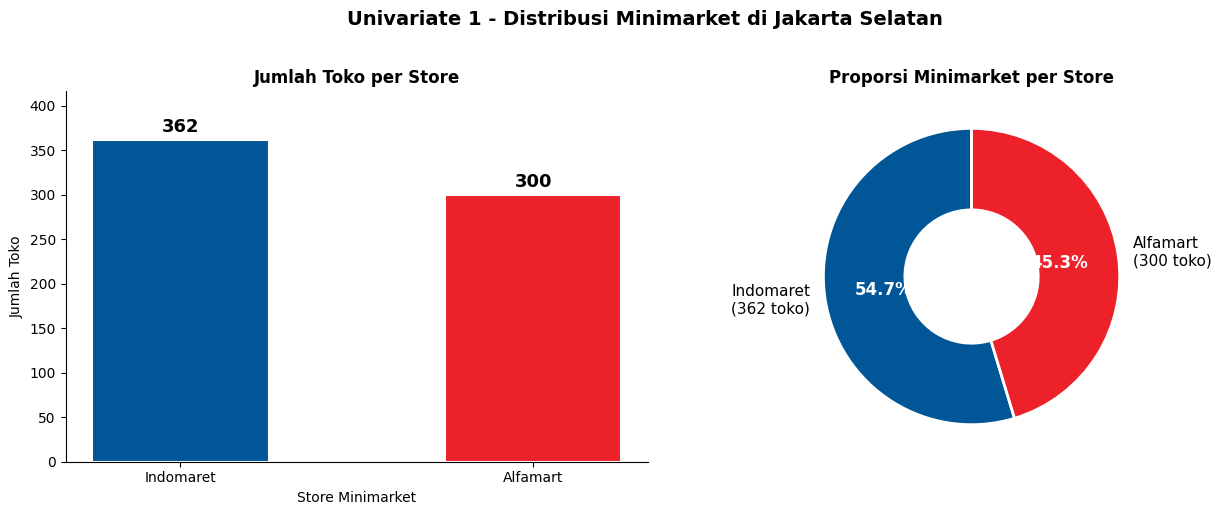

Grafik disimpan: viz_univariate_1_distribusi_store.png


In [36]:
# Grafik 1: Distribusi Store
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Univariate 1 - Distribusi Minimarket di Jakarta Selatan',
             fontsize=14, fontweight='bold', y=1.02)

store_counts = df_minimarket['store'].value_counts()

# Bar chart
ax1 = axes[0]
bars = ax1.bar(store_counts.index, store_counts.values,
               color=[WARNA_INDOMARET, WARNA_ALFAMART],
               width=0.5, edgecolor='white', linewidth=1.5)
for bar in bars:
    h = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, h + 4, f'{int(h)}',
             ha='center', va='bottom', fontweight='bold', fontsize=13)
ax1.set_title('Jumlah Toko per Store', fontsize=12, fontweight='bold')
ax1.set_xlabel('Store Minimarket')
ax1.set_ylabel('Jumlah Toko')
ax1.set_ylim(0, store_counts.max() * 1.15)
ax1.spines[['top','right']].set_visible(False)

# Donut chart
ax2 = axes[1]
labels_pie = [f'{n}\n({v} toko)' for n, v in zip(store_counts.index, store_counts.values)]
wedges, texts, autotexts = ax2.pie(
    store_counts.values, labels=labels_pie, autopct='%1.1f%%',
    colors=[WARNA_INDOMARET, WARNA_ALFAMART], startangle=90,
    wedgeprops={'width': 0.55, 'edgecolor': 'white', 'linewidth': 2},
    textprops={'fontsize': 11}
)
for at in autotexts:
    at.set_fontweight('bold'); at.set_color('white'); at.set_fontsize(12)
ax2.set_title('Proporsi Minimarket per Store', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('viz_univariate_1_distribusi_store.png', dpi=150, bbox_inches='tight')
plt.show()
print("Grafik disimpan: viz_univariate_1_distribusi_store.png")

#### Grafik 2: Distribusi Jarak ke Pasar Tradisional (Histogram + KDE)

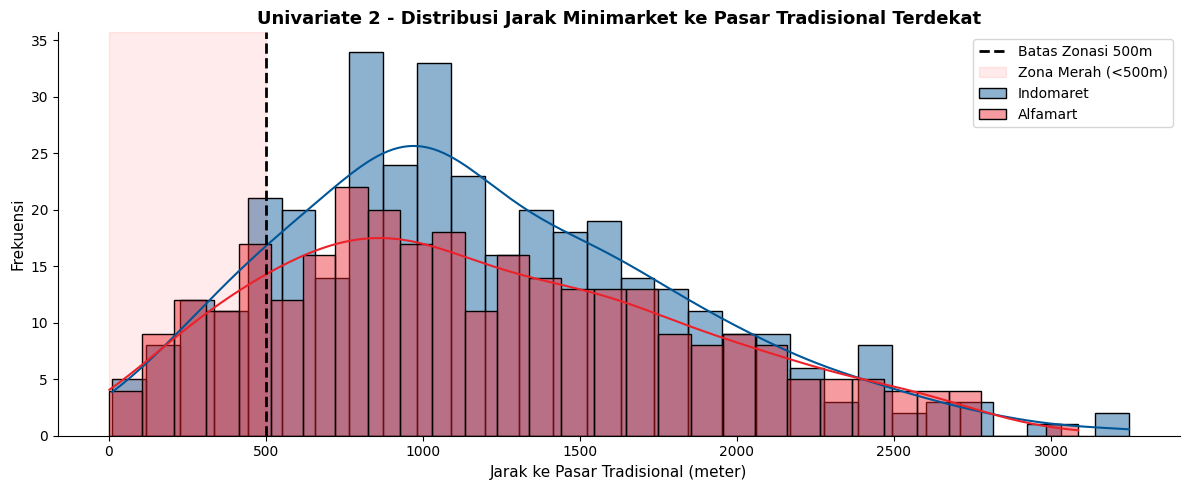

Grafik disimpan: viz_univariate_2_distribusi_jarak.png


In [37]:
# Grafik 2: Distribusi Jarak
fig, ax = plt.subplots(figsize=(12, 5))

for store, color in [('Indomaret', WARNA_INDOMARET), ('Alfamart', WARNA_ALFAMART)]:
    data = df_minimarket[df_minimarket['store'] == store]['jarak_pasar_meter']
    sns.histplot(data, bins=30, kde=True, color=color, alpha=0.45, label=store, ax=ax)

ax.axvline(x=500, color='black', linestyle='--', linewidth=2, label='Batas Zonasi 500m')
ax.axvspan(0, 500, alpha=0.08, color='red', label='Zona Merah (<500m)')
ax.set_title('Univariate 2 - Distribusi Jarak Minimarket ke Pasar Tradisional Terdekat',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Jarak ke Pasar Tradisional (meter)', fontsize=11)
ax.set_ylabel('Frekuensi', fontsize=11)
ax.legend(fontsize=10)
ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('viz_univariate_2_distribusi_jarak.png', dpi=150, bbox_inches='tight')
plt.show()
print("Grafik disimpan: viz_univariate_2_distribusi_jarak.png")

#### Grafik 3: Distribusi Jumlah Minimarket per Kecamatan

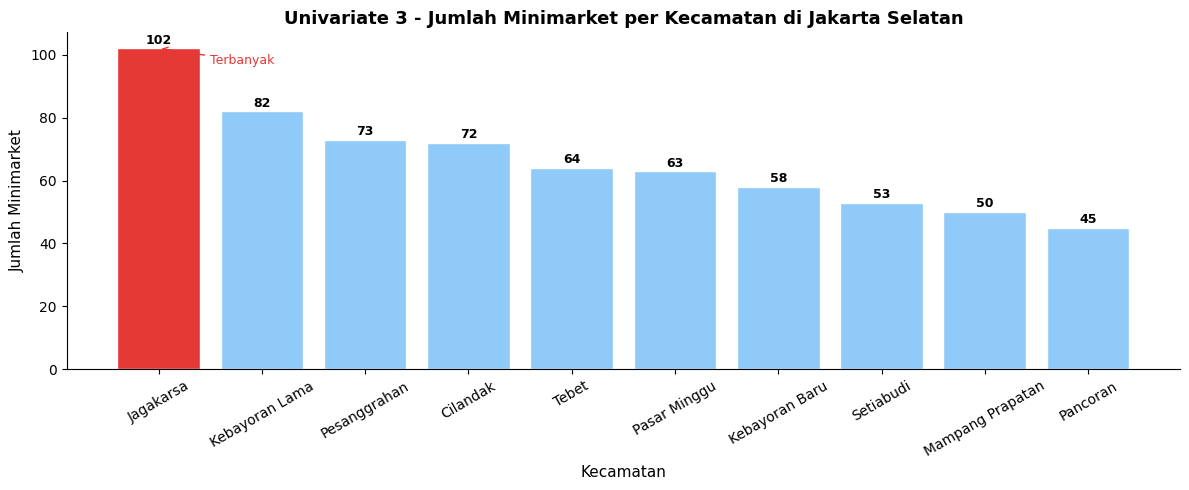

Grafik disimpan: viz_univariate_3_per_kecamatan.png


In [38]:
# Grafik 3: Per Kecamatan
df_minimarket_jaksel = df_minimarket[
    (df_minimarket['nama_kota'] == 'Kota Jakarta Selatan') &
    (df_minimarket['nama_kecamatan'].isin(KECAMATAN_JAKSEL))
]

fig, ax = plt.subplots(figsize=(12, 5))
kec_counts  = df_minimarket_jaksel['nama_kecamatan'].value_counts().sort_values(ascending=False)
colors_bar  = [WARNA_PELANGGARAN if v == kec_counts.max() else '#90CAF9' for v in kec_counts.values]
bars = ax.bar(kec_counts.index, kec_counts.values,
              color=colors_bar, edgecolor='white', linewidth=1)

for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.5, f'{int(h)}',
            ha='center', va='bottom', fontsize=9, fontweight='bold')

max_idx = kec_counts.idxmax()
max_val = kec_counts.max()
x_pos   = list(kec_counts.index).index(max_idx)
ax.annotate('Terbanyak', xy=(x_pos, max_val), xytext=(x_pos + 0.5, max_val - 5),
            fontsize=9, color=WARNA_PELANGGARAN,
            arrowprops=dict(arrowstyle='->', color=WARNA_PELANGGARAN))

ax.set_title('Univariate 3 - Jumlah Minimarket per Kecamatan di Jakarta Selatan',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Kecamatan', fontsize=11)
ax.set_ylabel('Jumlah Minimarket', fontsize=11)
ax.tick_params(axis='x', rotation=30)
ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('viz_univariate_3_per_kecamatan.png', dpi=150, bbox_inches='tight')
plt.show()
print("Grafik disimpan: viz_univariate_3_per_kecamatan.png")

---
Inisght:
---

1. Tertinggi: Kecamatan Jagakarsa memiliki jumlah minimarket terbanyak dengan 102 gerai (satu-satunya yang di atas 100).
2. Terendah: Kecamatan Pancoran memiliki jumlah paling sedikit, yaitu 45 gerai.
3. Pola Wilayah: Minimarket lebih padat di area pemukiman (seperti Jagakarsa dan Kebayoran Lama) dibandingkan di area pusat perkantoran/bisnis (seperti Setiabudi dan Mampang).

### Bivariate Analysis

#### Grafik 4: Komposisi Indomaret vs Alfamart per Kecamatan

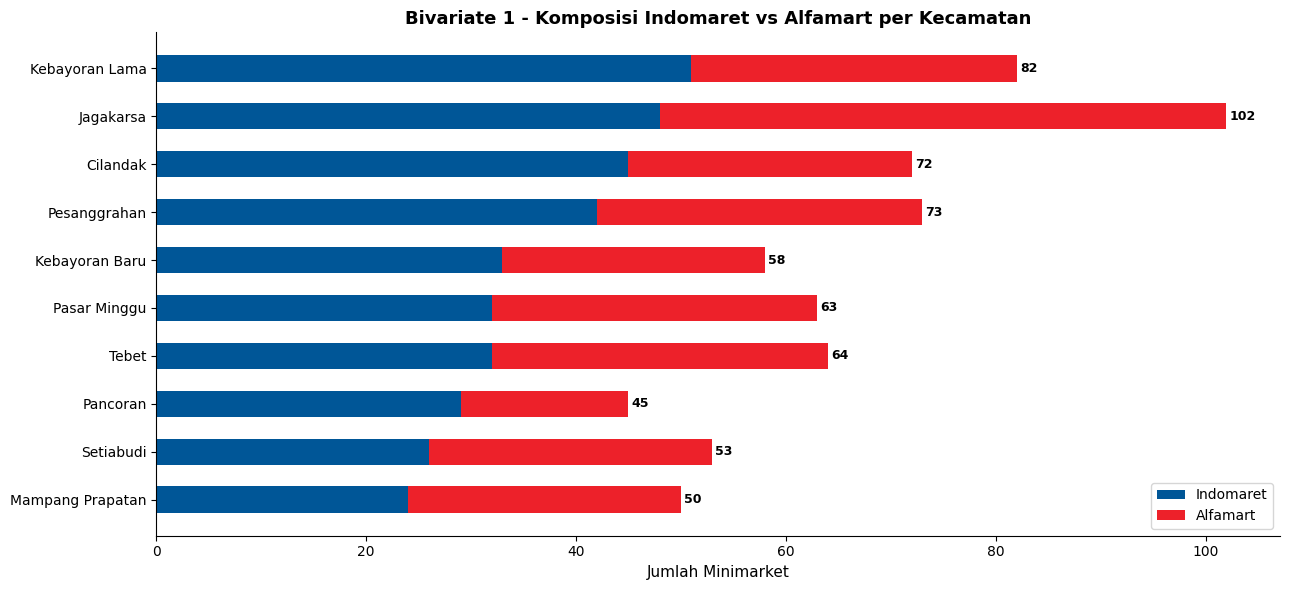

Grafik disimpan: viz_bivariate_1_komposisi_kecamatan.png


In [39]:
# Grafik 4: Stacked Bar per Kecamatan
dist_plot = distribusi_pivot[
    distribusi_pivot.index.isin(KECAMATAN_JAKSEL)
].drop(columns=['Total']).sort_values('Indomaret', ascending=True)

fig, ax = plt.subplots(figsize=(13, 6))
x     = range(len(dist_plot))
width = 0.55

ax.barh(list(x), dist_plot.get('Indomaret', [0]*len(dist_plot)),
        color=WARNA_INDOMARET, label='Indomaret', height=width)
ax.barh(list(x), dist_plot.get('Alfamart', [0]*len(dist_plot)),
        left=dist_plot.get('Indomaret', [0]*len(dist_plot)),
        color=WARNA_ALFAMART, label='Alfamart', height=width)

ax.set_yticks(list(x))
ax.set_yticklabels(dist_plot.index, fontsize=10)
ax.set_xlabel('Jumlah Minimarket', fontsize=11)
ax.set_title('Bivariate 1 - Komposisi Indomaret vs Alfamart per Kecamatan',
             fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.spines[['top','right']].set_visible(False)

for i, (idx, row) in enumerate(dist_plot.iterrows()):
    total = row.get('Indomaret', 0) + row.get('Alfamart', 0)
    ax.text(total + 0.3, i, f'{int(total)}', va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('viz_bivariate_1_komposisi_kecamatan.png', dpi=150, bbox_inches='tight')
plt.show()
print("Grafik disimpan: viz_bivariate_1_komposisi_kecamatan.png")

---
Inisght:
---

1. Dominasi Alfamart di Jagakarsa: Meski total minimarket paling banyak ada di Jagakarsa (102 gerai), porsi terbesarnya dikuasai oleh Alfamart (lebih dari setengah bar berwarna merah).
2. Indomaret Unggul di Kebayoran Lama: Kebayoran Lama menjadi satu-satunya kecamatan di mana Indomaret (warna biru) terlihat jelas memimpin jumlah gerai dibanding Alfamart.
3. Persaingan Ketat (Seimbang): Di beberapa wilayah seperti Cilandak, Pasar Minggu, dan Tebet, kekuatan keduanya relatif seimbang dengan pembagian porsi yang hampir sama rata (50:50).

#### Grafik 5: Analisis Pelanggaran Zonasi

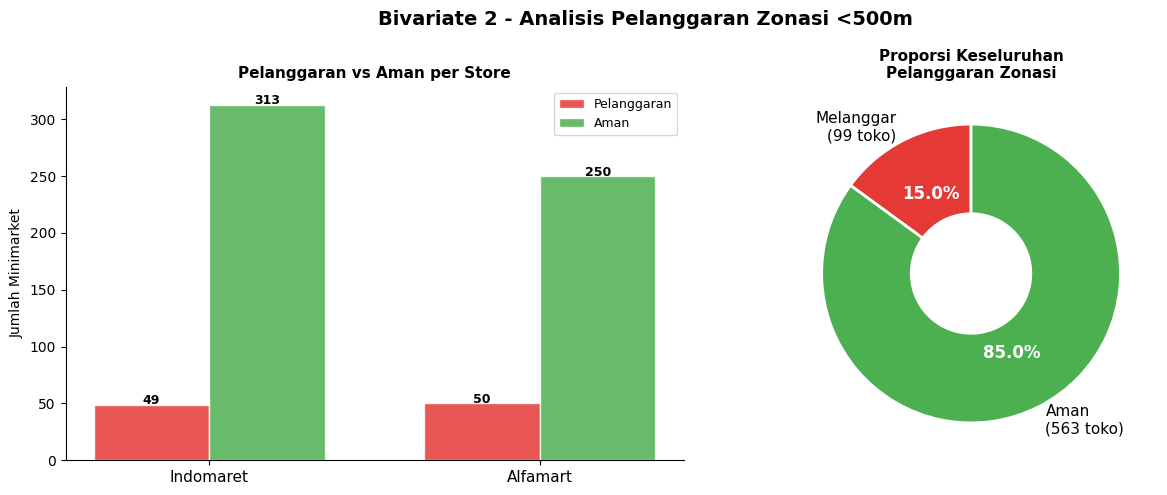

Grafik disimpan: viz_bivariate_2_pelanggaran_zonasi.png


In [40]:
# Grafik 5: Pelanggaran Zonasi

df_minimarket_jaksel = df_minimarket[
    (df_minimarket['nama_kota'] == 'Kota Jakarta Selatan') &
    (df_minimarket['nama_kecamatan'].isin(KECAMATAN_JAKSEL))
]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Bivariate 2 - Analisis Pelanggaran Zonasi <500m',
             fontsize=14, fontweight='bold')

ax1 = axes[0]
zon_store   = df_minimarket_jaksel.groupby(['store', 'pelanggaran_<500m']).size().reset_index(name='count')
x_pos       = np.arange(2)
store_list  = ['Indomaret', 'Alfamart']
status_list = ['Yes', 'No']

status_colors = [WARNA_PELANGGARAN, WARNA_AMAN]
bar_width = 0.35

for i, (status, color) in enumerate(zip(status_list, status_colors)):
    vals = [zon_store[(zon_store['store']==m) & (zon_store['pelanggaran_<500m']==status)]['count'].values
            for m in store_list]
    vals = [v[0] if len(v) > 0 else 0 for v in vals]
    bars = ax1.bar(x_pos + i*bar_width, vals, bar_width,
                   label='Pelanggaran' if status == 'Yes' else 'Aman',
                   color=color, alpha=0.85, edgecolor='white')
    for bar in bars:
        h = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2, h + 0.5, f'{int(h)}',
                 ha='center', fontsize=9, fontweight='bold')

ax1.set_xticks(x_pos + bar_width/2)
ax1.set_xticklabels(store_list, fontsize=11)
ax1.set_ylabel('Jumlah Minimarket')
ax1.set_title('Pelanggaran vs Aman per Store', fontsize=11, fontweight='bold')
ax1.legend(fontsize=9)
ax1.spines[['top','right']].set_visible(False)

ax2 = axes[1]
zon_counts = df_minimarket_jaksel['pelanggaran_<500m'].value_counts()
labels_p   = [f'Melanggar\n({zon_counts.get("Yes",0)} toko)',
               f'Aman\n({zon_counts.get("No",0)} toko)']
wedges, texts, autos = ax2.pie(
    [zon_counts.get('Yes',0), zon_counts.get('No',0)], labels=labels_p,
    autopct='%1.1f%%', colors=[WARNA_PELANGGARAN, WARNA_AMAN], startangle=90,
    wedgeprops={'width': 0.6, 'edgecolor':'white', 'linewidth':2},
    textprops={'fontsize':11}
)
for a in autos:
    a.set_fontweight('bold'); a.set_color('white'); a.set_fontsize(12)
ax2.set_title('Proporsi Keseluruhan\nPelanggaran Zonasi', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('viz_bivariate_2_pelanggaran_zonasi.png', dpi=150, bbox_inches='tight')
plt.show()
print("Grafik disimpan: viz_bivariate_2_pelanggaran_zonasi.png")

---
Inisght:
---

1. Tingkat Kepatuhan Tinggi: Secara keseluruhan, 85% toko (563 toko) sudah patuh/aman terhadap aturan zonasi, sementara yang melanggar hanya 15% (99 toko).
2. Jumlah Pelanggaran Setara: Dari segi jumlah, toko yang melanggar aturan zonasi antara Indomaret (49 toko) dan Alfamart (50 toko) hampir sama persis.
3. Rasio Pelanggaran Alfamart Lebih Tinggi: Karena total toko Alfamart (300 toko) lebih sedikit dibanding Indomaret (362 toko), maka secara persentase, tingkat pelanggaran di kubu Alfamart sedikit lebih tinggi dibandingkan Indomaret.

#### Grafik 6: Rata-rata Jarak ke Pasar per Kecamatan

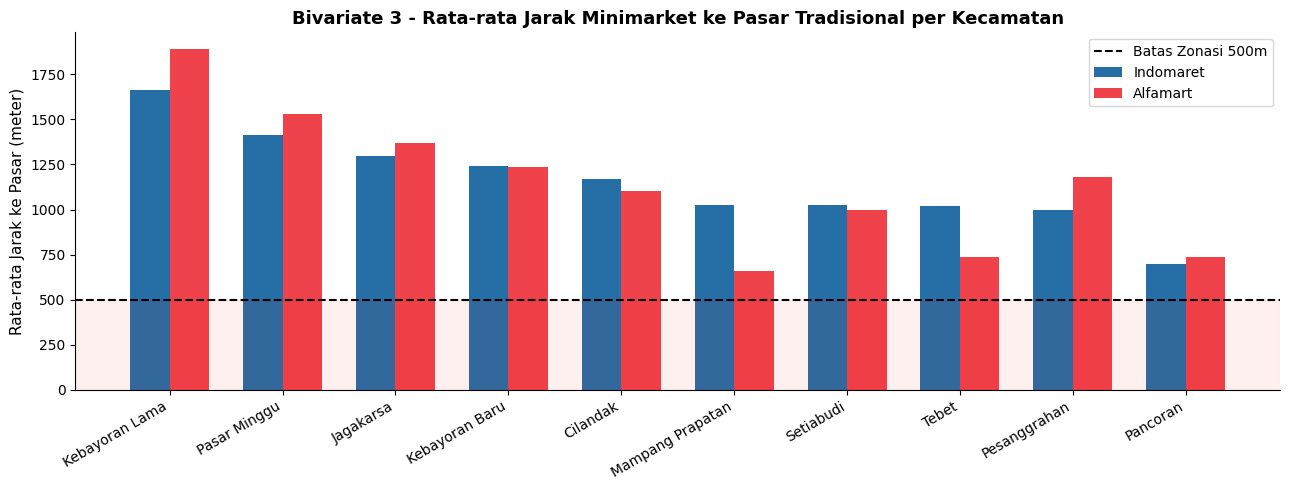

Grafik disimpan: viz_bivariate_3_jarak_per_kecamatan.png


In [41]:
# Grafik 6: Jarak Rata-rata per Kecamatan
jarak_kec   = df_minimarket_jaksel.groupby(['nama_kecamatan', 'store'])['jarak_pasar_meter'].mean().reset_index()
jarak_pivot = jarak_kec.pivot(index='nama_kecamatan', columns='store',
                               values='jarak_pasar_meter').fillna(0)
jarak_pivot = jarak_pivot.sort_values('Indomaret', ascending=False)

fig, ax = plt.subplots(figsize=(13, 5))
x     = np.arange(len(jarak_pivot))
width = 0.35

ax.bar(x - width/2, jarak_pivot.get('Indomaret', [0]*len(jarak_pivot)),
       width, label='Indomaret', color=WARNA_INDOMARET, alpha=0.85)
ax.bar(x + width/2, jarak_pivot.get('Alfamart', [0]*len(jarak_pivot)),
       width, label='Alfamart', color=WARNA_ALFAMART, alpha=0.85)
ax.axhline(y=500, color='black', linestyle='--', linewidth=1.5, label='Batas Zonasi 500m')
ax.axhspan(0, 500, alpha=0.06, color='red')

ax.set_xticks(x)
ax.set_xticklabels(jarak_pivot.index, rotation=30, ha='right', fontsize=10)
ax.set_ylabel('Rata-rata Jarak ke Pasar (meter)', fontsize=11)
ax.set_title('Bivariate 3 - Rata-rata Jarak Minimarket ke Pasar Tradisional per Kecamatan',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('viz_bivariate_3_jarak_per_kecamatan.png', dpi=150, bbox_inches='tight')
plt.show()
print("Grafik disimpan: viz_bivariate_3_jarak_per_kecamatan.png")

---
Inisght:
---

1. Zonasi Aman: Secara rata-rata di seluruh kecamatan, jarak Indomaret maupun Alfamart ke pasar tradisional berada di atas batas zonasi 500 meter (di luar area merah transparan).
2. Jarak Terjauh: Kecamatan Kebayoran Lama memiliki rata-rata jarak terjauh ke pasar tradisional (di atas 1500 meter) untuk kedua brand.
3. Jarak Terdekat: Kecamatan Pancoran memiliki rata-rata jarak paling dekat dengan pasar tradisional, mendekati batas minimal 500 meter.
4. Perbandingan Brand: Jarak rata-rata Indomaret (biru) dan Alfamart (merah) relatif mirip di sebagian besar kecamatan, kecuali di Mampang Prapatan dan Tebet di mana posisi Alfamart secara signifikan lebih dekat ke pasar tradisional dibanding Indomaret.

### Multivariate Analysis

#### Grafik 7: Peta Saturasi Kecamatan

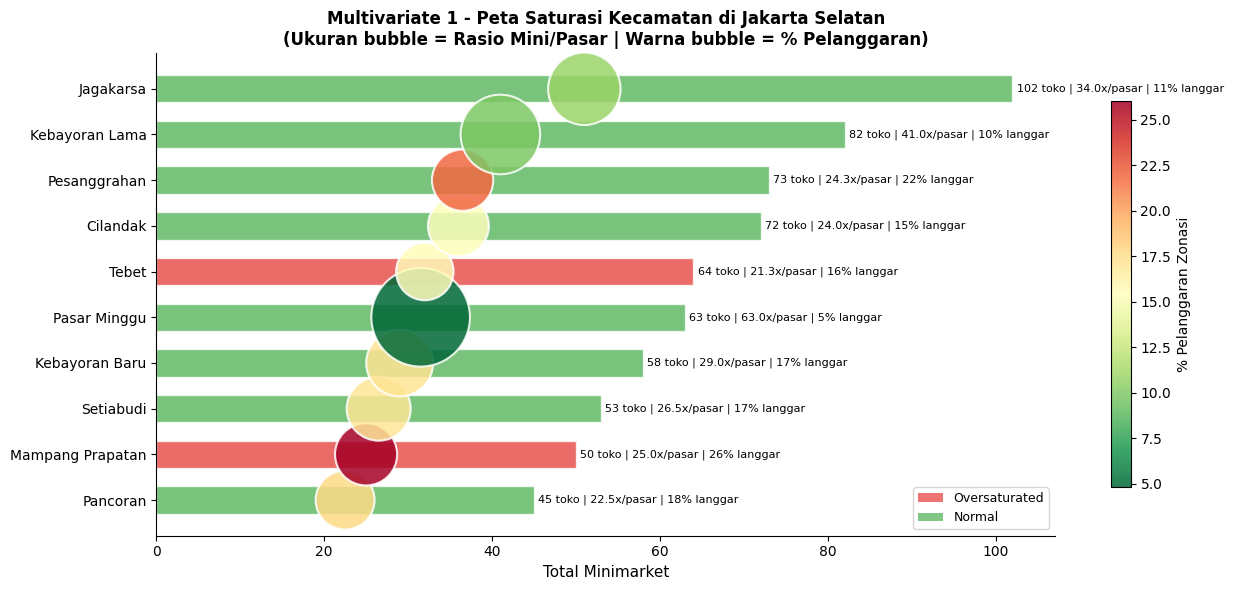

Grafik disimpan: viz_multivariate_1_saturasi_kecamatan_jaksel.png


In [42]:
# Grafik 7: Peta Saturasi
sat_plot = profil_jaksel[profil_jaksel['nama_kecamatan'].isin(KECAMATAN_JAKSEL)].copy()
sat_plot = sat_plot.sort_values('total_mini', ascending=True).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(13, 6))
kecamatan_names = sat_plot['nama_kecamatan']
x_pos = np.arange(len(sat_plot))

colors_sat = [WARNA_PELANGGARAN if 'OVERSATURATED' in str(s) else WARNA_AMAN
              for s in sat_plot['status']]

ax.barh(x_pos, sat_plot['total_mini'], color=colors_sat, alpha=0.75, height=0.6, edgecolor='white')

scatter = ax.scatter(
    sat_plot['total_mini'] / 2, x_pos,
    s=sat_plot['mini_per_pasar'] * 80,
    c=sat_plot['pct_pelanggaran'],
    cmap='RdYlGn_r', alpha=0.85, edgecolors='white', linewidth=1.5, zorder=5
)

for i, row in sat_plot.iterrows():
    ax.text(row['total_mini'] + 0.5, i,
            f"{int(row['total_mini'])} toko | {row['mini_per_pasar']:.1f}x/pasar | {row['pct_pelanggaran']:.0f}% langgar",
            va='center', fontsize=8)

cbar = plt.colorbar(scatter, ax=ax, shrink=0.8)
cbar.set_label('% Pelanggaran Zonasi', fontsize=10)

ax.set_yticks(x_pos)
ax.set_yticklabels(kecamatan_names, fontsize=10)
ax.set_xlabel('Total Minimarket', fontsize=11)
ax.set_title('Multivariate 1 - Peta Saturasi Kecamatan di Jakarta Selatan\n'
             '(Ukuran bubble = Rasio Mini/Pasar | Warna bubble = % Pelanggaran)',
             fontsize=12, fontweight='bold')
ax.spines[['top','right']].set_visible(False)

legend_elements = [
    mpatches.Patch(facecolor=WARNA_PELANGGARAN, alpha=0.7, label='Oversaturated'),
    mpatches.Patch(facecolor=WARNA_AMAN, alpha=0.7, label='Normal')
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9)

plt.tight_layout()
plt.savefig('viz_multivariate_1_saturasi_kecamatan_jaksel.png', dpi=150, bbox_inches='tight')
plt.show()
print("Grafik disimpan: viz_multivariate_1_saturasi_kecamatan_jaksel.png")

---
Inisght:
---

1. Konsentrasi & Saturasi Wilayah: Persebaran minimarket di Jakarta Selatan terpusat di beberapa kecamatan tertentu dengan tingkat kepadatan yang bervariasi.
2. Tiga Wilayah Teratas: Jagakarsa memimpin dengan jumlah minimarket terbanyak (102 toko), disusul Kebayoran Lama (82 toko), dan Pesanggrahan (73 toko).
3. Korelasi Jumlah vs Pelanggaran: Tingginya jumlah toko tidak otomatis mencerminkan tingginya pelanggaran zonasi. Contohnya, Pasar Minggu memiliki rasio tertinggi (63 toko per pasar), namun tingkat pelanggarannya sangat rendah (hanya ~5%) karena lokasinya yang menyebar.
4. Kategori Oversaturated (Saturasi Berlebih): Mampang Prapatan dan Tebet menjadi wilayah paling jenuh karena mencatat persentase pelanggaran zonasi tertinggi, masing-masing sebesar 26% dan 16%, akibat lokasi toko yang terlalu dekat dengan pasar tradisional.
5.Tekanan Spasial di Pesanggrahan: Meskipun tidak masuk kategori oversaturated, Pesanggrahan memiliki tingkat pelanggaran yang cukup tinggi (22%), menunjukkan adanya tekanan persaingan ruang yang besar terhadap pasar tradisional di wilayah tersebut.


#### Grafik 8: Top 10 Pasar Tradisional Paling Terancam

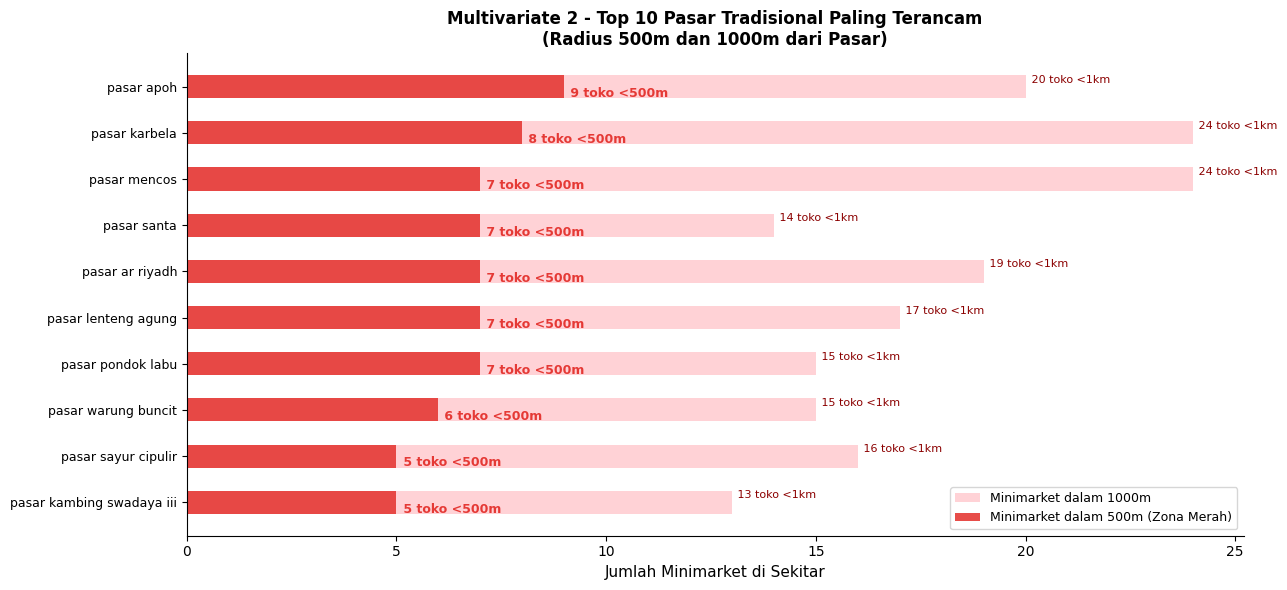

Grafik disimpan: viz_multivariate_2_pasar_terancam.png


In [43]:
# Grafik 8: Top 10 Pasar Terancam
top_ancaman = df_ancaman[df_ancaman['nama_kecamatan'].isin(KECAMATAN_JAKSEL)].copy()
top_ancaman = top_ancaman.head(10).sort_values('mini_dalam_500m', ascending=True)
y_pos = np.arange(len(top_ancaman))

fig, ax = plt.subplots(figsize=(13, 6))
ax.barh(y_pos, top_ancaman['mini_dalam_1000m'],
        height=0.5, color='#FFCDD2', label='Minimarket dalam 1000m', alpha=0.9)
ax.barh(y_pos, top_ancaman['mini_dalam_500m'],
        height=0.5, color=WARNA_PELANGGARAN, label='Minimarket dalam 500m (Zona Merah)', alpha=0.9)

for i, row in top_ancaman.reset_index().iterrows():
    if row['mini_dalam_500m'] > 0:
        ax.text(row['mini_dalam_500m'] + 0.05, i - 0.15,
                f" {int(row['mini_dalam_500m'])} toko <500m",
                va='center', fontsize=9, color=WARNA_PELANGGARAN, fontweight='bold')
    if row['mini_dalam_1000m'] > 0:
        y_lbl = i + 0.15 if row['mini_dalam_500m'] > 0 else i
        ax.text(row['mini_dalam_1000m'] + 0.05, y_lbl,
                f" {int(row['mini_dalam_1000m'])} toko <1km",
                va='center', fontsize=8, color='#8B0000')

ax.set_yticks(y_pos)
ax.set_yticklabels(top_ancaman['nama_pasar'], fontsize=9)
ax.set_xlabel('Jumlah Minimarket di Sekitar', fontsize=11)
ax.set_title('Multivariate 2 - Top 10 Pasar Tradisional Paling Terancam\n'
             '(Radius 500m dan 1000m dari Pasar)', fontsize=12, fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('viz_multivariate_2_pasar_terancam.png', dpi=150, bbox_inches='tight')
plt.show()
print("Grafik disimpan: viz_multivariate_2_pasar_terancam.png")

---
Inisght:
---
1. Pasar Paling Terancam (<500m): Pasar Apoh berada di posisi paling kritis dengan jumlah pelanggaran zonasi terdekat terbanyak, yaitu dikepung oleh 9 minimarket dalam radius kurang dari 500 meter.
2. Kepungan Radius Terluas (<1km): Pasar Karbela dan Pasar Mencos menjadi pasar yang paling padat dikelilingi ritel modern dalam jangkauan wilayah yang lebih luas, masing-masing memiliki 24 minimarket dalam radius kurang dari 1 kilometer.
3. Tingkat Kepadatan Tinggi yang Merata: Mayoritas pasar dalam daftar 10 besar ini (seperti Pasar Santa, Ar Riyadh, Lenteng Agung, dan Pondok Labu) secara seragam menghadapi ancaman langsung dari 7 minimarket di zona merah mereka (<500m).

#### Grafik 9: Heatmap Korelasi Metrik Spasial

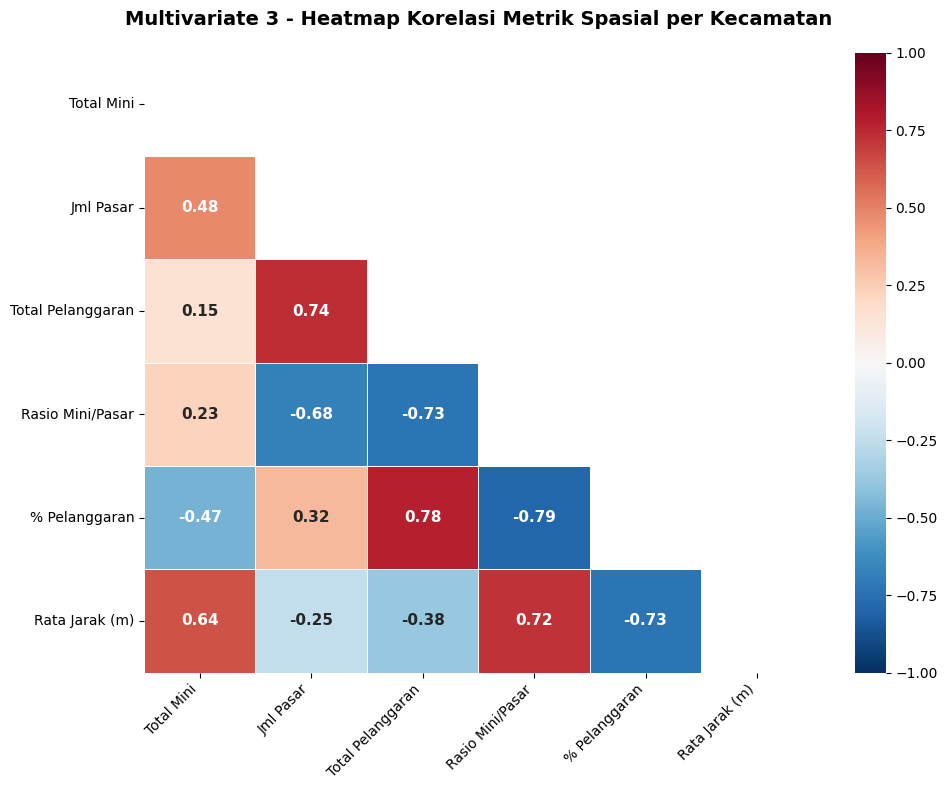

Grafik disimpan: viz_multivariate_3_heatmap_korelasi.png


In [44]:
# Grafik 9: Heatmap Korelasi
# FIX 5: profil_jaksel sekarang sudah tersedia.
saturasi_jaksel = profil_jaksel[profil_jaksel['nama_kecamatan'].isin(KECAMATAN_JAKSEL)].copy()

corr_data = saturasi_jaksel[['total_mini', 'jumlah_pasar', 'pelanggaran',
                              'mini_per_pasar', 'pct_pelanggaran', 'rata_jarak']].copy()
corr_data.columns = ['Total Mini', 'Jml Pasar', 'Total Pelanggaran',
                     'Rasio Mini/Pasar', '% Pelanggaran', 'Rata Jarak (m)']
corr_matrix = corr_data.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, linewidths=0.5, linecolor='white',
            annot_kws={'size': 11, 'weight': 'bold'}, ax=ax, vmin=-1, vmax=1)
ax.set_title('Multivariate 3 - Heatmap Korelasi Metrik Spasial per Kecamatan',
             fontsize=14, fontweight='bold', pad=20)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

plt.tight_layout()
plt.savefig('viz_multivariate_3_heatmap_korelasi.png', dpi=150, bbox_inches='tight')
plt.show()
print("Grafik disimpan: viz_multivariate_3_heatmap_korelasi.png")

---
Inisght:
---

1. Korelasi Positif Kuat (Sejalan): Total Pelanggaran & % Pelanggaran (0.78): Semakin banyak jumlah pelanggaran di suatu kecamatan, semakin tinggi pula persentase tingkat pelanggarannya secara keseluruhan.
    - Jml Pasar & Total Pelanggaran (0.74): Wilayah dengan jumlah pasar tradisional yang banyak cenderung memiliki jumlah kasus pelanggaran zonasi yang lebih tinggi.
    - Rasio Mini/Pasar & Rata Jarak (0.72): Semakin tinggi rasio jumlah minimarket terhadap pasar, rata-rata jarak antartoko cenderung semakin menjauh (menyebar).

2. Korelasi Negatif Kuat (Berbanding Terbalik):
    - Rasio Mini/Pasar & % Pelanggaran (-0.79): Kecamatan dengan rasio minimarket per pasar yang tinggi justru memiliki persentase pelanggaran yang lebih rendah (menandakan toko lebih menyebar ke area pemukiman, bukan menumpuk di sekitar pasar).
    - % Pelanggaran & Rata Jarak (-0.73): Semakin tinggi persentase pelanggaran zonasi, jarak rata-rata minimarket ke pasar semakin dekat (terkonsentrasi di zona terlarang).

3. Korelasi Lemah: * Total Mini & Total Pelanggaran (0.15): Jumlah total minimarket di suatu kecamatan hampir tidak memiliki pengaruh langsung terhadap banyaknya jumlah pelanggaran zonasi yang terjadi di wilayah tersebut.

---
## Data Storytelling & Kesimpulan

> *""*

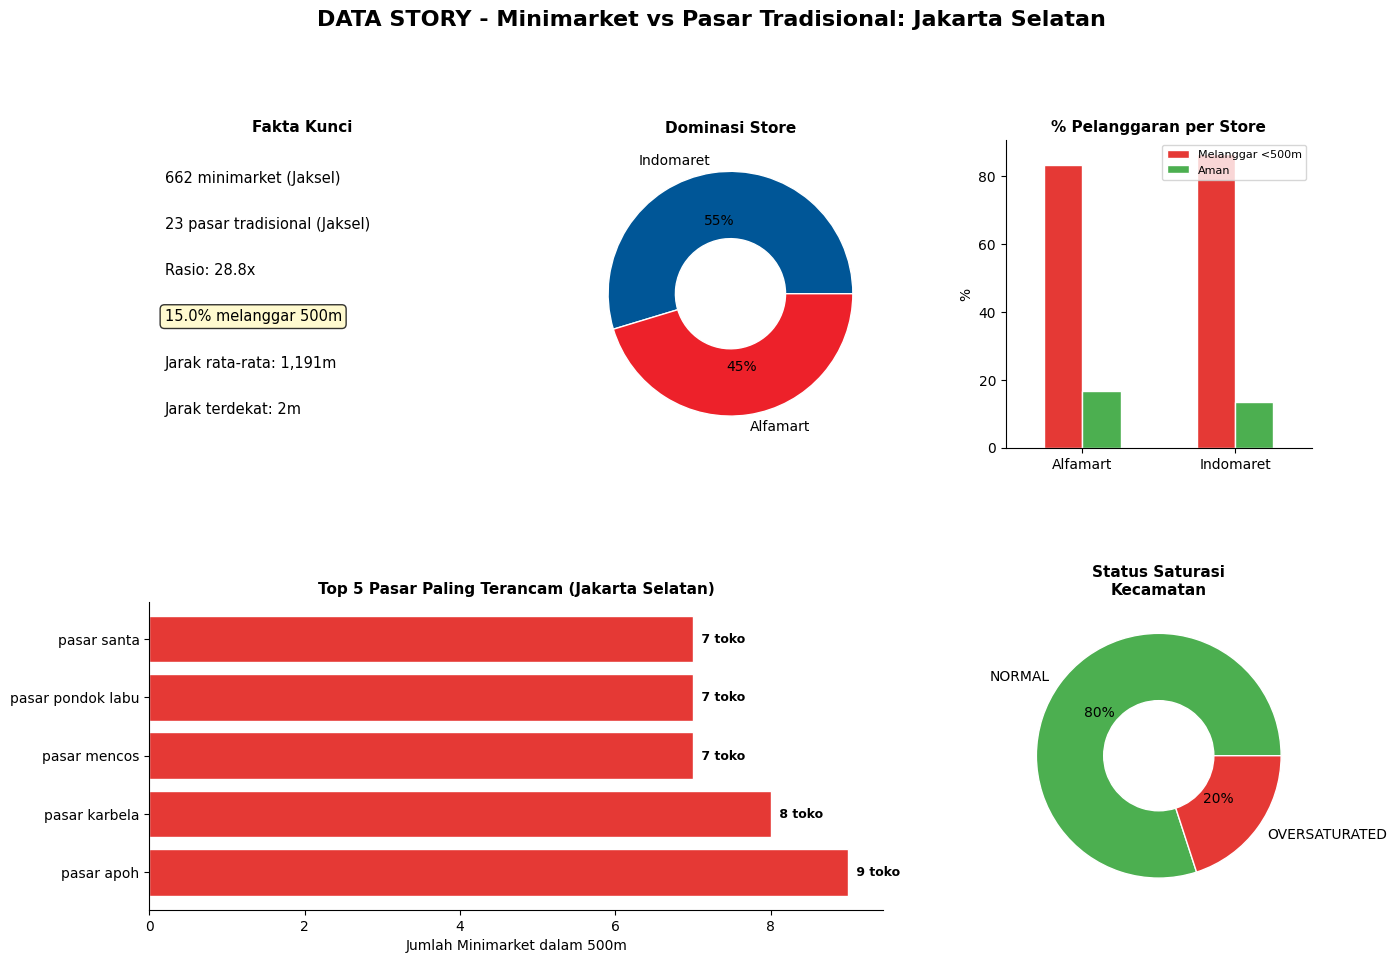

Dashboard Data Storytelling tersimpan.


In [45]:
# Dashboard Storytelling
df_m_jaksel       = df_minimarket[df_minimarket['nama_kecamatan'].isin(KECAMATAN_JAKSEL)].copy()
df_p_jaksel       = df_pasar[df_pasar['nama_kecamatan'].isin(KECAMATAN_JAKSEL)].copy()
df_ancaman_jaksel = df_ancaman[df_ancaman['nama_kecamatan'].isin(KECAMATAN_JAKSEL)].copy()

total_m   = len(df_m_jaksel)
total_p   = len(df_p_jaksel)
pct_l     = (df_m_jaksel['pelanggaran_<500m'] == 'Yes').sum() / total_m * 100 if total_m else 0
ratio     = total_m / total_p if total_p else 0

fig = plt.figure(figsize=(15, 10))
fig.suptitle('DATA STORY - Minimarket vs Pasar Tradisional: Jakarta Selatan',
             fontsize=16, fontweight='bold', y=1.01)
gs = fig.add_gridspec(2, 3, hspace=0.5, wspace=0.4)

# Panel 1: Fakta Kunci
ax0 = fig.add_subplot(gs[0, 0])
ax0.axis('off')
facts = [
    f"{total_m} minimarket (Jaksel)",
    f"{total_p} pasar tradisional (Jaksel)",
    f"Rasio: {ratio:.1f}x",
    f"{pct_l:.1f}% melanggar 500m",
    f"Jarak rata-rata: {df_m_jaksel['jarak_pasar_meter'].mean():,.0f}m",
    f"Jarak terdekat: {df_m_jaksel['jarak_pasar_meter'].min():,.0f}m"
]
for i, fact in enumerate(facts):
    ax0.text(0.05, 0.9 - i*0.15, fact, transform=ax0.transAxes, fontsize=10.5, va='top',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='#FFF9C4', alpha=0.8) if i == 3 else None)
ax0.set_title('Fakta Kunci', fontsize=11, fontweight='bold')

# Panel 2: Dominasi Store
ax1 = fig.add_subplot(gs[0, 1])
sc = df_m_jaksel['store'].value_counts()
ax1.pie(sc.values, labels=sc.index, autopct='%1.0f%%',
        colors=[WARNA_INDOMARET, WARNA_ALFAMART],
        wedgeprops={'width': 0.55, 'edgecolor': 'white'}, textprops={'fontsize': 10})
ax1.set_title('Dominasi Store', fontsize=11, fontweight='bold')

# Panel 3: % Pelanggaran per Store
ax2 = fig.add_subplot(gs[0, 2])
pv     = df_m_jaksel.groupby(['store', 'pelanggaran_<500m']).size().unstack(fill_value=0)
pv_pct = pv.div(pv.sum(axis=1), axis=0) * 100
pv_pct.plot(kind='bar', ax=ax2, color=[WARNA_PELANGGARAN, WARNA_AMAN],
            edgecolor='white', width=0.5)
ax2.set_title('% Pelanggaran per Store', fontsize=11, fontweight='bold')
ax2.set_xlabel('')
ax2.set_ylabel('%')
ax2.tick_params(axis='x', rotation=0)
ax2.legend(['Melanggar <500m', 'Aman'], fontsize=8)
ax2.spines[['top', 'right']].set_visible(False)

# Panel 4: Top 5 Pasar Terancam
ax3 = fig.add_subplot(gs[1, 0:2])
top5 = df_ancaman_jaksel.sort_values('mini_dalam_500m', ascending=False).head(5)
colors5 = [WARNA_PELANGGARAN if x > 0 else '#FFA726' for x in top5['mini_dalam_500m']]
ax3.barh(top5['nama_pasar'], top5['mini_dalam_500m'], color=colors5, edgecolor='white')
ax3.set_xlabel('Jumlah Minimarket dalam 500m')
ax3.set_title('Top 5 Pasar Paling Terancam (Jakarta Selatan)', fontsize=11, fontweight='bold')
ax3.spines[['top', 'right']].set_visible(False)
for i, v in enumerate(top5['mini_dalam_500m']):
    ax3.text(v + 0.05, i, f' {int(v)} toko', va='center', fontsize=9, fontweight='bold')

# Panel 5: Status Saturasi Kecamatan
ax4 = fig.add_subplot(gs[1, 2])
# FIX 6: status tidak mengandung emoji - langsung value_counts()
sat_count = profil_jaksel['status'].value_counts()
status_colors_map = {'OVERSATURATED': WARNA_PELANGGARAN, 'NORMAL': WARNA_AMAN}
ax4.pie(
    sat_count.values, labels=sat_count.index, autopct='%1.0f%%',
    colors=[status_colors_map.get(s, 'gray') for s in sat_count.index],
    wedgeprops={'width': 0.55, 'edgecolor': 'white'}, textprops={'fontsize': 10}
)
ax4.set_title('Status Saturasi\nKecamatan', fontsize=11, fontweight='bold')

plt.savefig('viz_storytelling_dashboard_fixed.png', dpi=150, bbox_inches='tight')
plt.show()
print("Dashboard Data Storytelling tersimpan.")

### Ringkasan & Validasi Akhir

In [46]:
# Ringkasan
total_mini_fin   = len(df_minimarket)
total_pasar_fin  = len(df_pasar)
total_langgar_fin = (df_minimarket['pelanggaran_<500m'] == 'Yes').sum()
pct_langgar_fin  = total_langgar_fin / total_mini_fin * 100
pasar_krisis     = df_ancaman[df_ancaman['mini_dalam_500m'] >= 3]['nama_pasar'].tolist()
kec_moratorium   = saturasi[saturasi['status'].str.contains('OVERSATURATED')]['nama_kecamatan'].tolist()
kec_ideal_top    = profil_jaksel.iloc[0]['nama_kecamatan']

print(" RINGKASAN ")
print(" Pemetaan Ritel Modern vs Pasar Tradisional - Jaksel")
print(f"\n Total minimarket aktif    : {total_mini_fin} toko")
print(f" Total pasar tradisional   : {total_pasar_fin} pasar")
print(f" Rasio minimarket/pasar    : {total_mini_fin/total_pasar_fin:.1f}x")
print(f"\n Pelanggaran <500m         : {total_langgar_fin} toko ({pct_langgar_fin:.1f}%)")

if pasar_krisis:
    print("\n Pasar dalam kondisi kritis:")
    for p in pasar_krisis[:5]: print(f"   - {p}")

if kec_moratorium:
    print("\n Kecamatan kandidat moratorium:")
    for k in kec_moratorium: print(f"   - {k}")

print(f"\n Kecamatan paling seimbang : {kec_ideal_top}")
print("\n Analisis selesai. Semua visualisasi berhasil dibuat.")

# Validasi Data
assert len(df_minimarket) > 600, f"Data terlalu sedikit: {len(df_minimarket)}"
assert df_minimarket['store'].isin(['Indomaret', 'Alfamart']).all(), "Ada nilai store tidak valid!"
assert df_minimarket['pelanggaran_<500m'].isin(['Yes', 'No']).all(), "Ada nilai pelanggaran tidak valid!"
print("\nSemua assertion validasi Bagus.")

 RINGKASAN 
 Pemetaan Ritel Modern vs Pasar Tradisional - Jaksel

 Total minimarket aktif    : 662 toko
 Total pasar tradisional   : 23 pasar
 Rasio minimarket/pasar    : 28.8x

 Pelanggaran <500m         : 99 toko (15.0%)

 Pasar dalam kondisi kritis:
   - pasar apoh
   - pasar karbela
   - pasar mencos
   - pasar pondok labu
   - pasar santa

 Kecamatan kandidat moratorium:
   - Tebet
   - Mampang Prapatan

 Kecamatan paling seimbang : Kebayoran Lama

 Analisis selesai. Semua visualisasi berhasil dibuat.

Semua assertion validasi Bagus.
